Imports

In [4]:
import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

packages = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "mysql.connector": "mysql-connector-python",
    "optuna": "optuna",
}

for import_name, pip_name in packages.items():
    try:
        __import__(import_name)
    except ImportError:
        install(pip_name)


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

# Données et base de données
import pandas as pd
import numpy as np
import mysql.connector

# Prétraitement
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Modèles
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Évaluation
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Tuning
import optuna

# Visualisation
import matplotlib.pyplot as plt

# Warnings
import warnings
warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

c:\Users\beaul\Documents\Université\S6\Sc données\GitHub\GamesSales\Visualisations\visu_donnees_gamesale\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Nettoyage et préparation des données

## Connexion à la DB

In [5]:
connexion = mysql.connector.connect(
    host     = 'localhost',
    user     = 'root',
    password = '',
    database = 'gamesale'
)

## Création des dataframe

In [6]:
# Table principale
df = pd.read_sql("""
    SELECT
        id_jeu,
        nom_jeu,
        age_requis,
        nb_succes,
        nb_avis_pos,
        nb_avis_neg,
        temps_jeu_moyen,
        prix,
        ventes_Global
    FROM jeux
""", connexion)

# Conversion ventes (virgule/point)
df['ventes_Global'] = df['ventes_Global'].str.replace(',', '.').astype(float)

# Genre (un seul par jeu, on prend le premier)
df_genre = pd.read_sql("""
    SELECT id_jeu, genre
    FROM genre
    GROUP BY id_jeu
""", connexion)

# Éditeur (un seul par jeu)
df_edit = pd.read_sql("""
    SELECT id_jeu, id_editeur
    FROM editeur
    GROUP BY id_jeu
""", connexion)

# Développeur (un seul par jeu)
df_dev = pd.read_sql("""
    SELECT id_jeu, id_developpeur
    FROM developpeur
    GROUP BY id_jeu
""", connexion)

# OS (colonnes binaires 0/1)
df_os = pd.read_sql("""
    SELECT
        id_jeu,
        MAX(CASE WHEN id_os = 1 THEN 1 ELSE 0 END) AS os_windows,
        MAX(CASE WHEN id_os = 2 THEN 1 ELSE 0 END) AS os_mac,
        MAX(CASE WHEN id_os = 3 THEN 1 ELSE 0 END) AS os_linux
    FROM a_os
    GROUP BY id_jeu
""", connexion)

# Catégories (colonnes binaires 0/1)
df_cat = pd.read_sql("""
    SELECT
        id_jeu,
        MAX(CASE WHEN id_cat = '1'  THEN 1 ELSE 0 END) AS cat_multi,
        MAX(CASE WHEN id_cat = '2'  THEN 1 ELSE 0 END) AS cat_online,
        MAX(CASE WHEN id_cat = '4'  THEN 1 ELSE 0 END) AS cat_vac,
        MAX(CASE WHEN id_cat = '5'  THEN 1 ELSE 0 END) AS cat_solo,
        MAX(CASE WHEN id_cat = '6'  THEN 1 ELSE 0 END) AS cat_cloud,
        MAX(CASE WHEN id_cat = '7'  THEN 1 ELSE 0 END) AS cat_achiev,
        MAX(CASE WHEN id_cat = '8'  THEN 1 ELSE 0 END) AS cat_cards,
        MAX(CASE WHEN id_cat = '10' THEN 1 ELSE 0 END) AS cat_ctrl,
        MAX(CASE WHEN id_cat = '22' THEN 1 ELSE 0 END) AS cat_workshop
    FROM a_categorie
    GROUP BY id_jeu
""", connexion)

# Nombre de tags par jeu
curseur = connexion.cursor()
curseur.execute("SELECT * FROM a_tag LIMIT 1")
curseur.fetchall()
toutes_cols   = [description[0] for description in curseur.description]
colonnes_tags = toutes_cols[1:]
somme_tags    = ' + '.join([f'`{col}`' for col in colonnes_tags])

df_tags = pd.read_sql(f"""
    SELECT id_jeu, ({somme_tags}) AS nb_tags
    FROM a_tag
""", connexion)

connexion.close()

## Fusion des dataframe

In [7]:
df = df.merge(df_genre, on='id_jeu', how='left')
df = df.merge(df_edit,  on='id_jeu', how='left')
df = df.merge(df_dev,   on='id_jeu', how='left')
df = df.merge(df_os,    on='id_jeu', how='left')
df = df.merge(df_cat,   on='id_jeu', how='left')
df = df.merge(df_tags,  on='id_jeu', how='left')

print(f"Après fusion : {len(df)} jeux, {len(df.columns)} colonnes")

Après fusion : 780 jeux, 25 colonnes


## Nettoyage des données

In [ ]:
# Supprimer les lignes avec des NaN dans les colonnes essentielles
df = df.dropna(subset=['ventes_Global', 'age_requis', 'prix'])

# Remplir les NaN restants
df['id_editeur']        = df['id_editeur'].fillna(-1).astype(int)
df['id_developpeur']    = df['id_developpeur'].fillna(-1).astype(int)
df['nb_tags']           = df['nb_tags'].fillna(0)
df = df.fillna(0)

print(len(df['id_editeur'].unique()))
print(len(df['id_editeur'].unique()))

print(df['genre'].unique())
print(df['id_editeur'].unique())
print(df['nb_tags'].unique())

print(f"Après nettoyage NaN : {len(df)} jeux")

225
<StringArray>
[      'Action',      'Shooter', 'Role-Playing',   'Simulation',
     'Fighting',    'Adventure',       'Racing',         'Misc',
     'Platform',     'Strategy',       'Sports',       'Puzzle']
Length: 12, dtype: str
[168   8 185  27  66 124 207  39 211 215  41 117 133 125   4  56 109  60
 174  51  33  24 196 140 145  16 192  98  28  75 205  50 164 102  25 147
  46 119  43 111  80 191 180  61 217   5 128 155  21 158 160  94 161 169
 203 131 186  91 222 104 116  86  54 173 139 144 118 127 184  74 188  93
 156 138 220 153  57 223 165  10 122  73 183 110  52 157 134  40 136 108
 193 103 107 148  44  82  69  45  15 130 137  48  29 218 132  77  53 141
  11  99  70 200 121 199 151 149   7  87 182 206 194  68 197 195  30  72
 210  14  71  79 181 115 152 172 201 214 106  22  64 179 177 171  18  58
 129  95 170 112 126 221 204  32 135   6 166 100  83 105  88  37 224  81
 120   2  17 219 154  35  49 175  78  67 123   3  89   9  84 187 213 198
 208  26 101  12  31  63 162  96  

## Suppression des valeurs aberrantes (quantile>0.9)
On les supprime car on a quelques jeux qui ont énormément bien marché (ex: GTA) mais c'est pas ce qui est le plus commun, ce qui tire la moyenne vers le haut, et donc nos modèles ont du mal à prédire les jeux "normaux". Ces valeurs aberrantes dégradent les performances de nos modèles sur les cas courants de jeux vidéo.

In [88]:
seuil_90 = df['ventes_Global'].quantile(0.90)
df = df[df['ventes_Global'] <= seuil_90]

print(f"Après suppression du top 10% (seuil={seuil_90:.2f}M) : {len(df)} jeux")

Après suppression du top 10% (seuil=3.80M) : 702 jeux


## Encodage des variables catégorielles non encodées (genre)

In [89]:
le_genre = LabelEncoder() #chaque catégorie est remplacée par un nombre entier
df['genre_enc'] = le_genre.fit_transform(df['genre'])

## Variables explicatives

In [90]:
variables_explicatives = [
    'age_requis',
    'nb_succes',
    'nb_avis_pos',
    'nb_avis_neg',
    'temps_jeu_moyen',
    'prix',
    'genre_enc',
    'id_editeur',
    'id_developpeur',
    'os_windows',
    'os_mac',
    'os_linux',
    'cat_multi',
    'cat_online',
    'cat_vac',
    'cat_solo',
    'cat_cloud',
    'cat_achiev',
    'cat_cards',
    'cat_ctrl',
    'cat_workshop',
    'nb_tags',
]

X   = df[variables_explicatives]
y   = df['ventes_Global'].values     # ventes réelles (en millions)
y_log = np.log1p(y)                  # ventes log pour SVR

print(f"\nDataset final : {X.shape[0]} jeux, {X.shape[1]} features")
print(f"Ventes :\nmin: {y.min():.2f}M - max: {y.max():.2f}M - moyenne: {y.mean():.2f}M")
print(f"\nVariables explicatives utilisées :\n")
for f in variables_explicatives:
    print(f"  - {f}")


Dataset final : 702 jeux, 22 features
Ventes :
min: 0.01M - max: 3.79M - moyenne: 0.64M

Variables explicatives utilisées :

  - age_requis
  - nb_succes
  - nb_avis_pos
  - nb_avis_neg
  - temps_jeu_moyen
  - prix
  - genre_enc
  - id_editeur
  - id_developpeur
  - os_windows
  - os_mac
  - os_linux
  - cat_multi
  - cat_online
  - cat_vac
  - cat_solo
  - cat_cloud
  - cat_achiev
  - cat_cards
  - cat_ctrl
  - cat_workshop
  - nb_tags


# Tuning et entraînement des modèles

## Random Forest

### Tuning train/test
Recherche des meilleurs hyperparamètres

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

meilleur_rmse = np.inf
r2_train_rf = None
meilleur_n, meilleur_depth, meilleur_split = None, None, None

for n_estimators in [100, 200, 300, 500]:
    for max_depth in [None, 5, 10, 15, 20]:
        for min_samples_split in [2, 5, 10]:

            rf = RandomForestRegressor(
                n_estimators     = n_estimators,
                max_depth        = max_depth,
                min_samples_split= min_samples_split,
                random_state     = 42
            )
            rf.fit(X_train, y_train)
            y_pred = rf.predict(X_test)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2= r2_score(y_test,y_pred)

            if rmse < meilleur_rmse:
                meilleur_rmse  = rmse
                r2_train_rf    = r2 
                meilleur_n     = n_estimators
                meilleur_depth = max_depth
                meilleur_split = min_samples_split

print(f"Meilleurs hyperparamètres : n_estimators={meilleur_n}, max_depth={meilleur_depth}, min_samples_split={meilleur_split}")
print(f"RMSE sur train/test : {meilleur_rmse:.3f}M")

Meilleurs hyperparamètres : n_estimators=500, max_depth=15, min_samples_split=10
RMSE sur train/test : 0.826M


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [92]:
#6mins40s pour faire tourner ce chunck avec un processeur 13th Gen Intel(R) Core(TM) i7-13620H (2.40 GHz)
loo = LeaveOneOut()
liste_reelles  = []
liste_predites = []

for train_idx, test_idx in loo.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    rf = RandomForestRegressor(
        n_estimators= meilleur_n,
        max_depth= meilleur_depth,
        min_samples_split= meilleur_split,
        random_state= 42,
        n_jobs=-1 #utilise tous les coeurs des processeurs car ça prenait + de 20mins
    )
    rf.fit(X_tr, y_tr)

    pred = rf.predict(X_te)[0]
    liste_predites.append(pred)
    liste_reelles.append(y_te[0])

y_pred_loo = np.array(liste_predites)
y_true_loo = np.array(liste_reelles)

### Résultats

In [93]:
rmse_rf = np.sqrt(mean_squared_error(y_true_loo, y_pred_loo))
mae_rf  = mean_absolute_error(y_true_loo, y_pred_loo)
r2_rf   = r2_score(y_true_loo, y_pred_loo)
y_pred_loo_rf = y_pred_loo.copy() #sauvegarde pour les graphiques

print(f"\nRésultats LOOCV - Random Forest")
print(f"  RMSE : {rmse_rf:.3f}M En moyenne le modèle se trompe de +-{rmse_rf:.2f} millions")
print(f"  MAE  : {mae_rf:.3f}M")
print(f"  R²   : {r2_rf:.3f}  Le modèle explique {r2_rf*100:.1f}% de la variance des ventes")


Résultats LOOCV - Random Forest
  RMSE : 0.763M En moyenne le modèle se trompe de +-0.76 millions
  MAE  : 0.550M
  R²   : 0.232  Le modèle explique 23.2% de la variance des ventes


## Gradient Boosting

### Tuning train/test et optuna
Recherche des meilleurs hyperparamètres. On utilise optuna qui cherche automatiquement les meilleurs hyperparamètres en 100 essais. Il oriente intelligemment les essais vers les meilleures combinaisons en minimisant le RMSE.

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500, step=50),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 2, 8),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }

    modele = GradientBoostingRegressor(**params, random_state=42)

    # On tune sur RMSE (donc on minimise MSE)
    scores = cross_val_score(
        modele, X_train, y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    return -scores.mean()  # on minimise donc on inverse

optuna.logging.set_verbosity(optuna.logging.WARNING) #enlève les messages d'info affiché à chaque trial

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)

study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Meilleurs hyperparamètres Optuna : {study.best_params}")
print(f"Meilleur RMSE (cross-val 5 folds) : {study.best_value:.3f}M")

meilleur_modele = GradientBoostingRegressor(**study.best_params, random_state=42)
meilleur_modele.fit(X_train, y_train)
y_pred = meilleur_modele.predict(X_test)
r2_train_gb = r2_score(y_test, y_pred)
meilleur_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE sur train/test : {meilleur_rmse:.3f}M")
print(f"R² sur train/test : {r2_train_gb:.3f}")

Best trial: 76. Best value: 0.728198: 100%|██████████| 100/100 [00:28<00:00,  3.49it/s]

Meilleurs hyperparamètres Optuna : {'n_estimators': 300, 'learning_rate': 0.037406986714046304, 'max_depth': 2, 'subsample': 0.798634733069636, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2'}
Meilleur RMSE (cross-val 5 folds) : 0.728M
RMSE sur train/test : 0.825M
R² sur train/test : 0.229


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [95]:
#Prend 2mins22s à tourner avec processeur 13th Gen Intel(R) Core(TM) i7-13620H (2.40 GHz)
loo = LeaveOneOut()
liste_reelles  = []
liste_predites = []

modele_final = GradientBoostingRegressor(**study.best_params, random_state=42)

for train_idx, test_idx in loo.split(X):
    # loo.split(X) génère à chaque tour :
    #   - train_idx : les indices des jeux utilisés pour l'entraînement
    #   - test_idx  : l'indice du jeu qu'on veut prédire (toujours 1 seul)

    # On découpe X et y en données d'entraînement et de test
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    #Entrainement
    # On entraîne le modèle sur les données d'entraînement
    modele_final.fit(X_tr, y_tr)

    #Prédiction 
    # On prédit les ventes du jeu de test
    # [0] car predict() retourne une liste, on veut juste le premier élément
    pred = modele_final.predict(X_te)[0]
    liste_predites.append(pred)
    liste_reelles.append(y_te[0])

# On stocke les résultats
y_pred_loo = np.array(liste_predites)
y_true_loo = np.array(liste_reelles)

### Résultats

In [96]:
rmse_gb = np.sqrt(mean_squared_error(y_true_loo, y_pred_loo))
mae_gb  = mean_absolute_error(y_true_loo, y_pred_loo)
r2_gb   = r2_score(y_true_loo, y_pred_loo)
y_pred_loo_gb = y_pred_loo.copy() #sauvegarde pour les graphiques

print(f"\nRésultats LOOCV - Gradient Boosting")
print(f"  RMSE : {rmse_gb:.3f}M  En moyenne le modèle se trompe de +-{rmse_gb:.2f} millions")
print(f"  MAE  : {mae_gb:.3f}M")
print(f"  R²   : {r2_gb:.3f}  Le modèle explique {r2_gb*100:.1f}% de la variance des ventes")


Résultats LOOCV - Gradient Boosting
  RMSE : 0.757M  En moyenne le modèle se trompe de +-0.76 millions
  MAE  : 0.542M
  R²   : 0.246  Le modèle explique 24.6% de la variance des ventes


## Support Vector Regression

### Tuning train/test
Recherche des meilleurs hyperparamètres

In [97]:
# Le SVR a besoin de y_log pour l'entraînement (stabilise la distribution)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Récupérer y réel pour les métriques
_, _, y_train_reel, y_test_reel = train_test_split(
    X, y, test_size=0.2, random_state=42
)

meilleur_rmse = np.inf
r2_train_svr = None
meilleur_C, meilleur_eps = None, None

for C in [0.1,0.5,1,2,3,4,5,6,7]:
    for eps in [0.35, 0.36,0.37,0.38]:

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        svr = SVR(kernel='rbf', C=C, epsilon=eps, gamma='scale')
        svr.fit(X_train_scaled, y_train_log)

        # Prédiction sur échelle réelle pour le RMSE
        y_pred_log  = svr.predict(X_test_scaled)
        y_pred_reel = np.expm1(y_pred_log)

        rmse = np.sqrt(mean_squared_error(y_test_reel, y_pred_reel))
        r2=r2_score(y_test_reel,y_pred_reel)

        if rmse < meilleur_rmse:
            meilleur_rmse = rmse
            r2_train_svr  = r2
            meilleur_C    = C
            meilleur_eps  = eps

print(f"Meilleurs hyperparamètres : C={meilleur_C}, epsilon={meilleur_eps}")
print(f"Meilleur RMSE sur train/test : {meilleur_rmse:.3f}M")

Meilleurs hyperparamètres : C=2, epsilon=0.36
Meilleur RMSE sur train/test : 0.867M


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [98]:
loo = LeaveOneOut()
liste_reelles  = []
liste_predites = []

for train_idx, test_idx in loo.split(X):
    X_tr, X_te   = X.iloc[train_idx], X.iloc[test_idx]
    y_tr_log     = y_log[train_idx]
    y_te_reel    = y[test_idx]

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    svr = SVR(kernel='rbf', C=meilleur_C, epsilon=meilleur_eps, gamma='scale')
    svr.fit(X_tr_scaled, y_tr_log)

    pred_log  = svr.predict(X_te_scaled)[0]
    pred_reel = np.expm1(pred_log)

    liste_predites.append(pred_reel)
    liste_reelles.append(float(y_te_reel[0]))

y_pred_loo = np.array(liste_predites)
y_true_loo = np.array(liste_reelles)

### Résultats

In [99]:
rmse_svr = np.sqrt(mean_squared_error(y_true_loo, y_pred_loo))
mae_svr  = mean_absolute_error(y_true_loo, y_pred_loo)
r2_svr   = r2_score(y_true_loo, y_pred_loo)
y_pred_loo_svr = y_pred_loo.copy() #sauvegarde pour les graphiques

print(f"\nRésultats LOOCV - SVR")
print(f"  RMSE : {rmse_svr:.3f}M  En moyenne le modèle se trompe de +-{rmse_svr:.2f} millions")
print(f"  MAE  : {mae_svr:.3f}M")
print(f"  R²   : {r2_svr:.3f}  Le modèle explique {r2_svr*100:.1f}% de la variance des ventes")


Résultats LOOCV - SVR
  RMSE : 0.810M  En moyenne le modèle se trompe de +-0.81 millions
  MAE  : 0.603M
  R²   : 0.135  Le modèle explique 13.5% de la variance des ventes


# Comparaison des modèles

## Tableau récapitulatif

In [100]:
resultats = {
    'Modèle':             ['Random Forest', 'Gradient Boosting', 'SVR'],
    'RMSE (M)':           [rmse_rf, rmse_gb, rmse_svr],
    'MAE (M)':            [mae_rf,  mae_gb,  mae_svr],
    'R²':                 [r2_rf,   r2_gb,   r2_svr],
}

df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values('RMSE (M)')
print(df_resultats.to_string(index=False))

           Modèle  RMSE (M)  MAE (M)       R²
Gradient Boosting  0.756607 0.542398 0.245719
    Random Forest  0.763283 0.549625 0.232351
              SVR  0.810418 0.602905 0.134614


## Comparaison RMSE et MAE

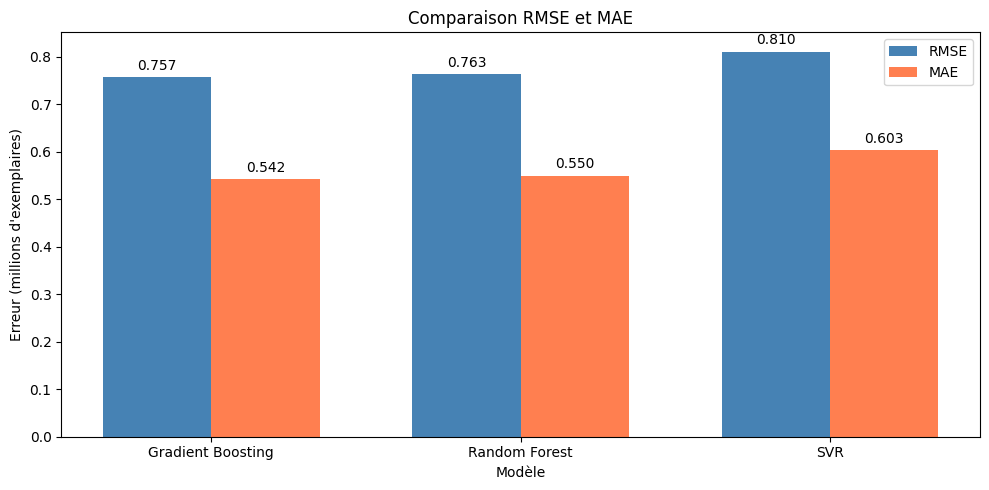

In [101]:
modeles = df_resultats['Modèle'].values
x = np.arange(len(modeles))
largeur = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
barres_rmse = ax.bar(x - largeur/2, df_resultats['RMSE (M)'], largeur, label='RMSE', color='steelblue')
barres_mae  = ax.bar(x + largeur/2, df_resultats['MAE (M)'],  largeur, label='MAE',  color='coral')

ax.set_xlabel('Modèle')
ax.set_ylabel('Erreur (millions d\'exemplaires)')
ax.set_title('Comparaison RMSE et MAE')
ax.set_xticks(x)
ax.set_xticklabels(modeles)
ax.legend()
ax.bar_label(barres_rmse, fmt='%.3f', padding=3)
ax.bar_label(barres_mae,  fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

### Analyse de la comparaison du RMSE et MAE
Ce graphique compare les **erreurs de prédiction** des trois modèles via le RMSE (root mean squared error) et le MAE (mean absolute error), toutes deux exprimées en millions d'exemplaires. L’objectif est d’obtenir un modèle présentant les valeurs de RMSE et de MAE les plus faibles possible.

Le RMSE mesure **l'écart moyen entre les valeurs prédites et les valeurs réelles** (ventes en millions), en accentuant les grandes erreurs du fait de la mise au carré. Le MAE mesure également cet écart moyen, mais de manière linéaire, sans donner de poids excessif aux erreurs importantes. Lorsque le RMSE est plus élevé que le MAE, cela indique que le modèle commet quelques erreurs particulièrement importantes qui tirent le RMSE vers le haut. Ces erreurs seraient moins visibles avec le MAE seul. L’utilisation conjointe des deux métriques informe à la fois sur la distribution des erreurs et sur leur magnitude.

**Gradient Boosting obtient les meilleurs résultats** avec un RMSE de 0,757M et un MAE de 0,542M. Random Forest est très proche, avec un RMSE de 0,763 et un MAE de 0,55M. SVR est nettement en retrait avec un RMSE de 0,810M et un MAE de 0,603M, soit des erreurs environ 7% supérieures aux deux autres modèles.

**L'écart entre RMSE et MAE pour tous les modèles (environ 0,20M) suggère la présence de valeurs aberrantes (ApX Machine Learning, 2024)**, notamment des jeux très populaires dont les ventes sont difficiles à prédire. La constance de cet écart d'un modèle à l'autre montre que ces erreurs ne sont pas dues aux choix de modélisation, mais s'expliquent par les données de notre dataset.

## Comparaison des R²

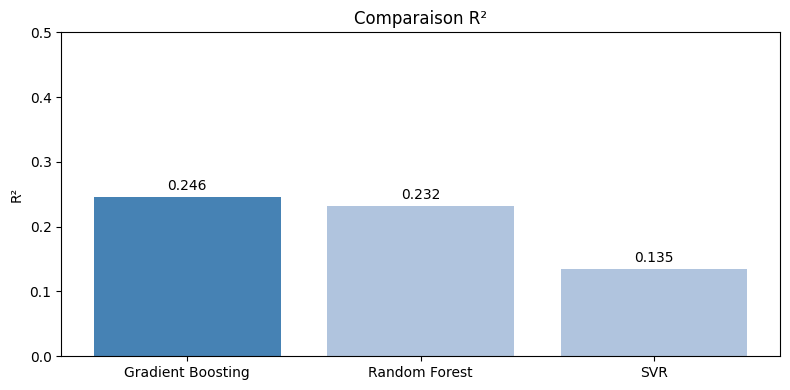

In [102]:
fig, ax = plt.subplots(figsize=(8, 4))
couleurs = ['steelblue' if r == df_resultats['R²'].max() else 'lightsteelblue' for r in df_resultats['R²']]
barres = ax.bar(modeles, df_resultats['R²'], color=couleurs)
ax.set_ylabel('R²')
ax.set_title('Comparaison R²')
ax.set_ylim(0, 0.5)
ax.bar_label(barres, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
print(f"R² train GB : {r2_train_gb:.3f} R² GB LOOCV : {r2_gb:.3f}")
print(f"R² train RF : {r2_train_rf:.3f} R² RF LOOCV : {r2_rf:.3f}")
print(f"R² train SVR : {r2_train_svr:.3f} R² SVR LOOCV : {r2_svr:.3f}")

R² train GB : 0.22885004315783064 R² GB LOOCV : 0.24571922070667018
R² train RF : 0.22671110795891303 R² RF LOOCV : 0.23235054556152135
R² train SVR : 0.14817941663135126 R² SVR LOOCV : 0.13461391061945882


### Analyse de la comparaison des R²
Ce graphique met en évidence la part de la **variance expliquée** par chaque modèle. Un R² de 1 indique une explication complète des données, alors qu'un R² de 0 indique l'absence de pouvoir explicatif. Gradient Boosting est le meilleur avec R²=0,246, suivi de Random Forest (R²=0,232) et SVR (R²=0,135). Ces scores indiquent que **même le modèle avec le R² le plus élevé, Gradient Boosting, n'explique que 24,6% de la variance du nombre de ventes**. Un R² inferieur à 0,3 est vraiment faible. Ça veut dire que près de 75% du nombre de nos ventes reste inexpliqué par les variables utilisées. Cela suggère que les features actuelles du dataset sont insuffisantes pour capturer les facteurs déterminants des ventes.

Avant de parler de l'overfitting, expliquons ce que c'est. C'est quand un modèle apprend les données d'entraînement au point de les connaître par coeur au lieu d'apprendre les tendances générales. Donc il marche bien sur l'entraînement mais ensuite il a du mal.

Au niveau de l'overfitting, le gradient boosting et le random forest ont un r² légèrement supérieur au train/test. Il n'y a donc pas d'overfitting. Par contre, le SVR a une légère baisse (0.148 à 0.135). C'est un petit écart, il n'y a donc pas d'overfitting significatif.

Modifier les variables données à notre modèle pourrait aider à mieux expliquer le nombre de ventes des jeux vidéos.

## Valeurs réelles vs prédites

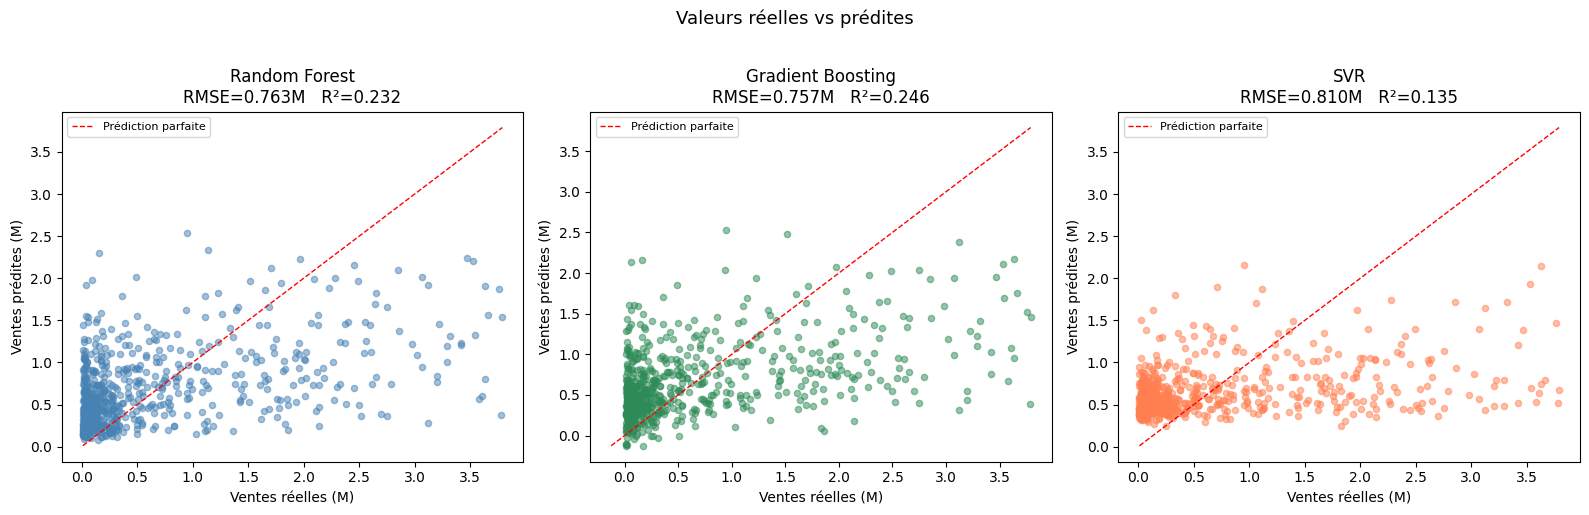

In [104]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

donnees = [
    ('Random Forest', y_true_loo, y_pred_loo_rf, rmse_rf, r2_rf, 'steelblue'),
    ('Gradient Boosting', y_true_loo, y_pred_loo_gb, rmse_gb, r2_gb, 'seagreen'),
    ('SVR', y_true_loo, y_pred_loo_svr, rmse_svr, r2_svr, 'coral'),
]

for ax, (nom, y_true, y_pred, rmse, r2, couleur) in zip(axes, donnees):
    ax.scatter(y_true, y_pred, alpha=0.5, color=couleur, s=20)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1, label='Prédiction parfaite')
    ax.set_title(f'{nom}\nRMSE={rmse:.3f}M   R²={r2:.3f}')
    ax.set_xlabel('Ventes réelles (M)')
    ax.set_ylabel('Ventes prédites (M)')
    ax.legend(fontsize=8)

plt.suptitle('Valeurs réelles vs prédites', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Analyse de la comparaison des valeurs réelles vs prédites
Sur ces graphiques, on **compare les vraies ventes (axe horizontal) aux ventes prédites (axe vertical) par chaque modèle**. La **ligne rouge pointillée** représente la **prédiction parfaite** : quand un point est dessus, le modèle a deviné exactement la bonne valeur. Si un point est au dessus, alors le modèle sur estime le nombre de ventes, et en dessous, il la sous estime.

- Gradient Boosting :
Avec un RMSE de 0.757 et un R² = 0.24, Gradient Boosting est le plus performant des trois. Ses points s'alignent relativement mieux autour de la ligne rouge pour les ventes faibles à moyennes (0-1.5M). Cependant, comme les autres modèles, il sous-estime systématiquement les ventes élevées (>2M), où les points s'éloignent nettement de la diagonale.

- Random Forest :
Random Forest affiche des résultats très proches (RMSE=0.763, R²=0.232). La distribution de ses points (en bleu) est similaire à celle du Gradient Boosting, avec une légère dispersion supplémentaire pour les ventes entre 0 et 1M. Il échoue lui aussi à prédire les valeurs au dessus de 2M.

- SVR :
Le SVR en orange est clairement le moins performant. Avec son RMSE=0.810 et le R²=0.135, on voit rapidement visuellement qu'il y a une compression des prédictions basse, contrairement aux dispersions des deux autres modèles. Ce modèle prédit rarement au delà de 1,5M de ventes, quelle que soit la valeur réelle. Il n'arrive pas à prédire les ventes élevées.

**Pour conclure, Gradient Boosting est le meilleur des trois modèles. Il a à la fois le RMSE le plus faible et le R² le plus élevé. Il reste néanmoins mauvais sur les valeures extrêmes, comme les autres modèles.**

# Importance des variables dans nos prédictions
Pour calculer l'importance des variables, il faut que l'on entraîne chaque modèle sur tout le dataset

In [105]:
noms_variables = variables_explicatives  # liste des noms de colonnes

## Random Forest
Pour le modèle random forest, feature_importances_ est intégré pour calculer l'importance des varibales explicatives. Il calcule pour chaque variable combien de fois elle a été utilisée pour faire des coupures dans les arbres, et à quel point ces coupures ont réduit l'erreur ou non

In [106]:
rf_final = RandomForestRegressor(
    n_estimators     = meilleur_n,
    max_depth        = meilleur_depth,
    min_samples_split= meilleur_split,
    random_state     = 42,
    n_jobs           = -1
)
rf_final.fit(X, y)

importances_rf = pd.Series(rf_final.feature_importances_, index=noms_variables)
importances_rf = importances_rf.sort_values()

## Gradient Boosting
Ici aussi, feature_importances_ est intégré

In [107]:
gb_final = GradientBoostingRegressor(**study.best_params, random_state=42)
gb_final.fit(X, y)

importances_gb = pd.Series(gb_final.feature_importances_, index=noms_variables)
importances_gb = importances_gb.sort_values()

## SVR
Pour le SVR, il n'y a pas d'attribut pour calculer l'importance des variables explicatives. 
On doit donc faire une permutation importance. On entraîne le modèle normalement, puis pour chaque variable on mélange aléatoirement ses valeurs entre tous les jeux. Ensuite, on regarde si les prédictions sont moins bonnes qu'avant ou non. Si les prédictions se dégradent, c'est que la variable était importante. Sinon elle était inutile. Le score peut être négatif puisque l'on fait score_original - score_apres_melange. Si il est négatif, c'est que le score est meilleur qu'avant et donc la variable introduisait du bruit, et le modèle marche mieux sans.

In [108]:
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

svr_final = SVR(kernel='rbf', C=meilleur_C, epsilon=meilleur_eps, gamma='scale')
svr_final.fit(X_scaled, y_log)

result = permutation_importance(
    svr_final, X_scaled, y_log,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances_svr = pd.Series(result.importances_mean, index=noms_variables)
importances_svr = importances_svr.sort_values()

## Graphiques

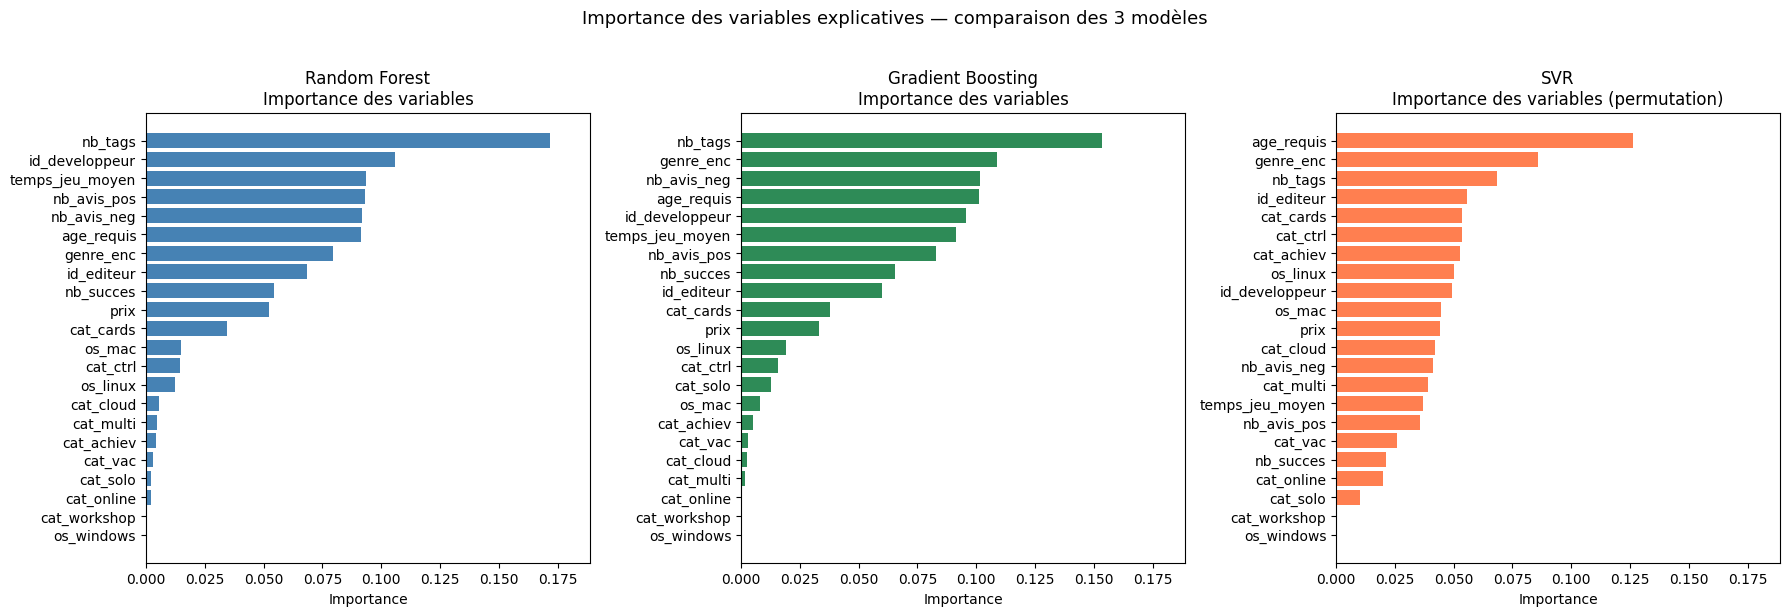

In [109]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Valeur max globale
max_importance = max(
    importances_rf.max(), 
    importances_gb.max(), 
    importances_svr.max()
)

# Random Forest
axes[0].barh(importances_rf.index, importances_rf.values, color='steelblue')
axes[0].set_title('Random Forest\nImportance des variables')
axes[0].set_xlabel('Importance')
axes[0].set_xlim(0, max_importance * 1.1)

# Gradient Boosting
axes[1].barh(importances_gb.index, importances_gb.values, color='seagreen')
axes[1].set_title('Gradient Boosting\nImportance des variables')
axes[1].set_xlabel('Importance')
axes[1].set_xlim(0, max_importance * 1.1)

# SVR
axes[2].barh(importances_svr.index, importances_svr.values, color='coral')
axes[2].set_title('SVR\nImportance des variables (permutation)')
axes[2].set_xlabel('Importance')
axes[2].set_xlim(0, max_importance * 1.1)

plt.suptitle('Importance des variables explicatives — comparaison des 3 modèles', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Analyse des graphes sur l'importance des variables

Chaque graphe correspond à un modèle différent de machine learning, et **affiche dans l'ordre les variables les plus explicatives du modèle**. C'est-à-dire, **les variables qui permettent au modèle de faire au mieux ses prédictions**.

**Important à savoir :** l'importance des variables explicatives dans le graphe SVR a été calculée différemment, par permutation. Cette méthode peut produire des valeurs négatives si une variable dégrade les performances du modèle.

Pour le modèle SVR, aucune variable n'est négative. Donc, aucune variable ne dégrade les prédictions.
On observe également que l'importance est plus uniformément répartie entre les variables que dans les autres modèles : environ un tiers des variables dépassent 0.04.

Pour Random Forest et Gradient Boosting, on observe que les variables les plus importantes sont concentrées sur quelques variables, contrairement au SVR. Dans Random Forest, les 3 premières variables ("nb_tags","id_developpeur","temps_jeu_moyen") représentent à elles seules une part importante. Gradient Boosting est similaire, avec "nb_tags" et "genre_enc" en tête, mais avec une distribution légèrement plus étalée sur les variables suivantes.


Concernant les valeurs observées dans leur globalité, on remarque que la variable "nb_tags" est toujours bien classée, que ce soit avec le modèle Random Forest et Gradient Boosting où il est premier ou encore avec le modèle SVR où il est troisième. Dans le cas du modèle Random Forest, "nb_tags" représente environ 17% de l'importance totale du modèle. **Pour Gradient Boosting, "nb_tags" environ 16% de l'importance totale du modèle**. Ces valeurs sont plutôt grandes pour le jeu de données que nous avons.

On voit également que la variable "id_developpeur" est bien classée dans les deux modèles Random Forest et Gradient Boosting, étant respectivement deuxième et cinquième.


3 variables ressortent sur les 3 modèles :
- La variable **"nb_tags" est importante partout**. On peut penser qu'un jeu avec beaucoup de tags Steam est probablement plus populaire.
- La variable "genre_enc" compte pour les modèles Gradient Boosting et SVR.
- La variable "id_developpeur" compte beaucoup pour Random Forest et Gradient Boosting. Ainsi, le studio qui développe le jeu influence les ventes.

Pour terminer, on constate que **l'importance de certaines variables est propre à leur modèle**. "age_requis" est la variable la plus importante pour le SVR, mais est moyenne pour Random Forest et Gradient Boosting.
Quant à la variable "os_windows", elle est quasi nulle pour les 3 modèles, ce qui est logique car presque tous les jeux Steam sont sur Windows, donc ça n'a pas d'influence.

**Beaucoup de variables sont très peu utiles** pour chaque modèle car elles sont tout le temps proches de 0 :
- cat_workshop, cat_online, cat_solo, cat_vac

Ces catégories ne permettent donc pas d'expliquer les ventes d'un jeu.

# Modèles de prédiction pour les jeux à succès modéré
Puisque nos modèles ne fonctionnent pas très bien, mais qu'on remarque 2 catégories dans les prédictions (les jeux qui font peu de ventes sont surestimés alors que les jeux faisant des ventes moyennes sont sous estimés) on a décidé d'essayer de créer 2 types de modèles prédictifs : un modèle pour les jeux faisant des ventes moyennes (pour les développeurs un peu connus en général) et les jeux faisant de petites ventes (souvent des indépendants). Nous allons tout d'abord entraîner nos modèles sur les jeux ayant un succès modéré.

# Nettoyage et préparation des données

## Connexion à la DB

In [110]:
connexion = mysql.connector.connect(
    host     = 'localhost',
    user     = 'root',
    password = '',
    database = 'gamesale'
)

## Création des dataframe

In [111]:
# Table principale
df = pd.read_sql("""
    SELECT
        id_jeu,
        nom_jeu,
        age_requis,
        nb_succes,
        nb_avis_pos,
        nb_avis_neg,
        temps_jeu_moyen,
        prix,
        ventes_Global
    FROM jeux
""", connexion)

# Conversion ventes (virgule/point)
df['ventes_Global'] = df['ventes_Global'].str.replace(',', '.').astype(float)

# Genre (un seul par jeu, on prend le premier)
df_genre = pd.read_sql("""
    SELECT id_jeu, genre
    FROM genre
    GROUP BY id_jeu
""", connexion)

# Éditeur (un seul par jeu)
df_edit = pd.read_sql("""
    SELECT id_jeu, id_editeur
    FROM editeur
    GROUP BY id_jeu
""", connexion)

# Développeur (un seul par jeu)
df_dev = pd.read_sql("""
    SELECT id_jeu, id_developpeur
    FROM developpeur
    GROUP BY id_jeu
""", connexion)

# OS (colonnes binaires 0/1)
df_os = pd.read_sql("""
    SELECT
        id_jeu,
        MAX(CASE WHEN id_os = 1 THEN 1 ELSE 0 END) AS os_windows,
        MAX(CASE WHEN id_os = 2 THEN 1 ELSE 0 END) AS os_mac,
        MAX(CASE WHEN id_os = 3 THEN 1 ELSE 0 END) AS os_linux
    FROM a_os
    GROUP BY id_jeu
""", connexion)

# Catégories (colonnes binaires 0/1)
df_cat = pd.read_sql("""
    SELECT
        id_jeu,
        MAX(CASE WHEN id_cat = '1'  THEN 1 ELSE 0 END) AS cat_multi,
        MAX(CASE WHEN id_cat = '2'  THEN 1 ELSE 0 END) AS cat_online,
        MAX(CASE WHEN id_cat = '4'  THEN 1 ELSE 0 END) AS cat_vac,
        MAX(CASE WHEN id_cat = '5'  THEN 1 ELSE 0 END) AS cat_solo,
        MAX(CASE WHEN id_cat = '6'  THEN 1 ELSE 0 END) AS cat_cloud,
        MAX(CASE WHEN id_cat = '7'  THEN 1 ELSE 0 END) AS cat_achiev,
        MAX(CASE WHEN id_cat = '8'  THEN 1 ELSE 0 END) AS cat_cards,
        MAX(CASE WHEN id_cat = '10' THEN 1 ELSE 0 END) AS cat_ctrl,
        MAX(CASE WHEN id_cat = '22' THEN 1 ELSE 0 END) AS cat_workshop
    FROM a_categorie
    GROUP BY id_jeu
""", connexion)

# Nombre de tags par jeu
curseur = connexion.cursor()
curseur.execute("SELECT * FROM a_tag LIMIT 1")
curseur.fetchall()
toutes_cols   = [description[0] for description in curseur.description]
colonnes_tags = toutes_cols[1:]
somme_tags    = ' + '.join([f'`{col}`' for col in colonnes_tags])

df_tags = pd.read_sql(f"""
    SELECT id_jeu, ({somme_tags}) AS nb_tags
    FROM a_tag
""", connexion)

connexion.close()

## Fusion des dataframe

In [112]:
df = df.merge(df_genre, on='id_jeu', how='left')
df = df.merge(df_edit,  on='id_jeu', how='left')
df = df.merge(df_dev,   on='id_jeu', how='left')
df = df.merge(df_os,    on='id_jeu', how='left')
df = df.merge(df_cat,   on='id_jeu', how='left')
df = df.merge(df_tags,  on='id_jeu', how='left')

print(f"Après fusion : {len(df)} jeux, {len(df.columns)} colonnes")

Après fusion : 780 jeux, 25 colonnes


## Nettoyage des données

In [113]:
# Supprimer les lignes avec des NaN dans les colonnes essentielles
df = df.dropna(subset=['ventes_Global', 'age_requis', 'prix'])

# Remplir les NaN restants
df['genre']          = df['genre'].fillna('Unknown')
df['id_editeur']     = df['id_editeur'].fillna(-1).astype(int)
df['id_developpeur'] = df['id_developpeur'].fillna(-1).astype(int)
df['nb_tags']        = df['nb_tags'].fillna(0)
df = df.fillna(0)

print(f"Après nettoyage NaN : {len(df)} jeux")

Après nettoyage NaN : 780 jeux


## On garde les jeux à succès modéré
Ce sont des jeux qui ont fait entre 0.19M et 1.69M de ventes.

In [114]:
seuil_90= df['ventes_Global'].quantile(0.9)
seuil_50 = df['ventes_Global'].quantile(0.5)
df = df[(df['ventes_Global'] <= seuil_90) & (df['ventes_Global'] >= seuil_50)]

print(f"Après avoir gardé les jeux entre le 7ème et le 9ème décile : {len(df)} jeux")

Après avoir gardé les jeux entre le 7ème et le 9ème décile : 321 jeux


## Encodage des variables catégorielles non encodées (genre)

In [115]:
le_genre = LabelEncoder() #chaque catégorie est remplacée par un nombre entier
df['genre_enc'] = le_genre.fit_transform(df['genre'])

## Variables explicatives

In [116]:
variables_explicatives = [
    'age_requis',
    'nb_succes',
    'nb_avis_pos',
    'nb_avis_neg',
    'temps_jeu_moyen',
    'prix',
    'genre_enc',
    'id_editeur',
    'id_developpeur',
    'os_windows',
    'os_mac',
    'os_linux',
    'cat_multi',
    'cat_online',
    'cat_vac',
    'cat_solo',
    'cat_cloud',
    'cat_achiev',
    'cat_cards',
    'cat_ctrl',
    'cat_workshop',
    'nb_tags',
]

X   = df[variables_explicatives]
y   = df['ventes_Global'].values     # ventes réelles (en millions)
y_log = np.log1p(y)                  # ventes log pour SVR

print(f"\nDataset final : {X.shape[0]} jeux, {X.shape[1]} features")
print(f"Ventes :\nmin: {y.min():.2f}M - max: {y.max():.2f}M - moyenne: {y.mean():.2f}M")
print(f"\nVariables explicatives utilisées :\n")
for f in variables_explicatives:
    print(f"  - {f}")


Dataset final : 321 jeux, 22 features
Ventes :
min: 0.27M - max: 3.79M - moyenne: 1.29M

Variables explicatives utilisées :

  - age_requis
  - nb_succes
  - nb_avis_pos
  - nb_avis_neg
  - temps_jeu_moyen
  - prix
  - genre_enc
  - id_editeur
  - id_developpeur
  - os_windows
  - os_mac
  - os_linux
  - cat_multi
  - cat_online
  - cat_vac
  - cat_solo
  - cat_cloud
  - cat_achiev
  - cat_cards
  - cat_ctrl
  - cat_workshop
  - nb_tags


# Tuning et entraînement des modèles

## Random Forest

### Tuning train/test
Recherche des meilleurs hyperparamètres

In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

meilleur_rmse = np.inf
r2_train_rf = None
meilleur_n, meilleur_depth, meilleur_split = None, None, None

for n_estimators in [100, 200, 300, 500]:
    for max_depth in [None, 5, 10, 15, 20]:
        for min_samples_split in [2, 5, 10]:

            rf = RandomForestRegressor(
                n_estimators     = n_estimators,
                max_depth        = max_depth,
                min_samples_split= min_samples_split,
                random_state     = 42
            )
            rf.fit(X_train, y_train)
            y_pred = rf.predict(X_test)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2= r2_score(y_test,y_pred)

            if rmse < meilleur_rmse:
                meilleur_rmse  = rmse
                r2_train_rf    = r2 
                meilleur_n     = n_estimators
                meilleur_depth = max_depth
                meilleur_split = min_samples_split

print(f"Meilleurs hyperparamètres : n_estimators={meilleur_n}, max_depth={meilleur_depth}, min_samples_split={meilleur_split}")
print(f"RMSE sur train/test : {meilleur_rmse:.3f}M")

Meilleurs hyperparamètres : n_estimators=100, max_depth=10, min_samples_split=10
RMSE sur train/test : 0.825M


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [118]:
#6mins40s pour faire tourner ce chunck avec un processeur 13th Gen Intel(R) Core(TM) i7-13620H (2.40 GHz)
loo = LeaveOneOut()
liste_reelles  = []
liste_predites = []

for train_idx, test_idx in loo.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    rf = RandomForestRegressor(
        n_estimators= meilleur_n,
        max_depth= meilleur_depth,
        min_samples_split= meilleur_split,
        random_state= 42,
        n_jobs=-1 #utilise tous les coeurs des processeurs car ça prenait + de 20mins
    )
    rf.fit(X_tr, y_tr)

    pred = rf.predict(X_te)[0]
    liste_predites.append(pred)
    liste_reelles.append(y_te[0])

y_pred_loo = np.array(liste_predites)
y_true_loo = np.array(liste_reelles)

### Résultats

In [119]:
rmse_rf = np.sqrt(mean_squared_error(y_true_loo, y_pred_loo))
mae_rf  = mean_absolute_error(y_true_loo, y_pred_loo)
r2_rf   = r2_score(y_true_loo, y_pred_loo)
y_pred_loo_rf = y_pred_loo.copy() #sauvegarde pour les graphiques

print(f"\nRésultats LOOCV - Random Forest")
print(f"  RMSE : {rmse_rf:.3f}M En moyenne le modèle se trompe de ±{rmse_rf:.2f} millions")
print(f"  MAE  : {mae_rf:.3f}M")
print(f"  R²   : {r2_rf:.3f}  Le modèle explique {r2_rf*100:.1f}% de la variance des ventes")


Résultats LOOCV - Random Forest
  RMSE : 0.846M En moyenne le modèle se trompe de ±0.85 millions
  MAE  : 0.679M
  R²   : 0.177  Le modèle explique 17.7% de la variance des ventes


## Gradient Boosting

### Tuning train/test et optuna
Recherche des meilleurs hyperparamètres. On utilise optuna qui cherche automatiquement les meilleurs hyperparamètres en 100 essais. Il oriente intelligemment les essais vers les meilleures combinaisons en minimisant le RMSE.

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500, step=50),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 2, 8),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }

    modele = GradientBoostingRegressor(**params, random_state=42)

    # On tune sur RMSE (donc on minimise MSE)
    scores = cross_val_score(
        modele, X_train, y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    return -scores.mean()  # on minimise donc on inverse

optuna.logging.set_verbosity(optuna.logging.WARNING) #enlève les messages d'info affiché à chaque trial

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)

study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Meilleurs hyperparamètres Optuna : {study.best_params}")
print(f"Meilleur RMSE (cross-val 5 folds) : {study.best_value:.3f}M")

meilleur_modele = GradientBoostingRegressor(**study.best_params, random_state=42)
meilleur_modele.fit(X_train, y_train)
y_pred = meilleur_modele.predict(X_test)
r2_train_gb = r2_score(y_test, y_pred)
meilleur_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE sur train/test : {meilleur_rmse:.3f}M")
print(f"R² sur train/test : {r2_train_gb:.3f}")

Best trial: 86. Best value: 0.818655: 100%|██████████| 100/100 [00:21<00:00,  4.69it/s]


Meilleurs hyperparamètres Optuna : {'n_estimators': 200, 'learning_rate': 0.02543303816118474, 'max_depth': 7, 'subsample': 0.7511929108118649, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2'}
Meilleur RMSE (cross-val 5 folds) : 0.819M
RMSE sur train/test : 0.849M
R² sur train/test : 0.248


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [121]:
#Prend 2mins22s à tourner avec processeur 13th Gen Intel(R) Core(TM) i7-13620H (2.40 GHz)
loo = LeaveOneOut()
liste_reelles  = []
liste_predites = []

modele_final = GradientBoostingRegressor(**study.best_params, random_state=42)

for train_idx, test_idx in loo.split(X):
    # loo.split(X) génère à chaque tour :
    #   - train_idx : les indices des jeux utilisés pour l'entraînement
    #   - test_idx  : l'indice du jeu qu'on veut prédire (toujours 1 seul)

    # On découpe X et y en données d'entraînement et de test
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    #Entrainement
    # On entraîne le modèle sur les données d'entraînement
    modele_final.fit(X_tr, y_tr)

    #Prédiction 
    # On prédit les ventes du jeu de test
    # [0] car predict() retourne une liste, on veut juste le premier élément
    pred = modele_final.predict(X_te)[0]
    liste_predites.append(pred)
    liste_reelles.append(y_te[0])

# On stocke les résultats
y_pred_loo = np.array(liste_predites)
y_true_loo = np.array(liste_reelles)

### Résultats

In [122]:
rmse_gb = np.sqrt(mean_squared_error(y_true_loo, y_pred_loo))
mae_gb  = mean_absolute_error(y_true_loo, y_pred_loo)
r2_gb   = r2_score(y_true_loo, y_pred_loo)
y_pred_loo_gb = y_pred_loo.copy() #sauvegarde pour les graphiques

print(f"\nRésultats LOOCV - Gradient Boosting")
print(f"  RMSE : {rmse_gb:.3f}M  En moyenne le modèle se trompe de +-{rmse_gb:.2f} millions")
print(f"  MAE  : {mae_gb:.3f}M")
print(f"  R²   : {r2_gb:.3f}  Le modèle explique {r2_gb*100:.1f}% de la variance des ventes")


Résultats LOOCV - Gradient Boosting
  RMSE : 0.833M  En moyenne le modèle se trompe de +-0.83 millions
  MAE  : 0.669M
  R²   : 0.202  Le modèle explique 20.2% de la variance des ventes


## Support Vector Regression

### Tuning train/test
Recherche des meilleurs hyperparamètres

In [123]:
# Le SVR a besoin de y_log pour l'entraînement (stabilise la distribution)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Récupérer y réel pour les métriques
_, _, y_train_reel, y_test_reel = train_test_split(
    X, y, test_size=0.2, random_state=42
)

meilleur_rmse = np.inf
r2_train_svr = None
meilleur_C, meilleur_eps = None, None

for C in [0.1,0.5,1,2,3,4,5,6,7]:
    for eps in [0.35, 0.36,0.37,0.38]:

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        svr = SVR(kernel='rbf', C=C, epsilon=eps, gamma='scale')
        svr.fit(X_train_scaled, y_train_log)

        # Prédiction sur échelle réelle pour le RMSE
        y_pred_log  = svr.predict(X_test_scaled)
        y_pred_reel = np.expm1(y_pred_log)

        rmse = np.sqrt(mean_squared_error(y_test_reel, y_pred_reel))
        r2=r2_score(y_test_reel,y_pred_reel)

        if rmse < meilleur_rmse:
            meilleur_rmse = rmse
            r2_train_svr  = r2
            meilleur_C    = C
            meilleur_eps  = eps

print(f"Meilleurs hyperparamètres : C={meilleur_C}, epsilon={meilleur_eps}")
print(f"Meilleur RMSE sur train/test : {meilleur_rmse:.3f}M")

Meilleurs hyperparamètres : C=1, epsilon=0.38
Meilleur RMSE sur train/test : 0.879M


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [124]:
loo = LeaveOneOut()
liste_reelles  = []
liste_predites = []

for train_idx, test_idx in loo.split(X):
    X_tr, X_te   = X.iloc[train_idx], X.iloc[test_idx]
    y_tr_log     = y_log[train_idx]
    y_te_reel    = y[test_idx]

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    svr = SVR(kernel='rbf', C=meilleur_C, epsilon=meilleur_eps, gamma='scale')
    svr.fit(X_tr_scaled, y_tr_log)

    pred_log  = svr.predict(X_te_scaled)[0]
    pred_reel = np.expm1(pred_log)

    liste_predites.append(pred_reel)
    liste_reelles.append(float(y_te_reel[0]))

y_pred_loo = np.array(liste_predites)
y_true_loo = np.array(liste_reelles)

### Résultats

In [125]:
rmse_svr = np.sqrt(mean_squared_error(y_true_loo, y_pred_loo))
mae_svr  = mean_absolute_error(y_true_loo, y_pred_loo)
r2_svr   = r2_score(y_true_loo, y_pred_loo)
y_pred_loo_svr = y_pred_loo.copy() #sauvegarde pour les graphiques

print(f"\nRésultats LOOCV - SVR")
print(f"  RMSE : {rmse_svr:.3f}M  En moyenne le modèle se trompe de +-{rmse_svr:.2f} millions")
print(f"  MAE  : {mae_svr:.3f}M")
print(f"  R²   : {r2_svr:.3f}  Le modèle explique {r2_svr*100:.1f}% de la variance des ventes")


Résultats LOOCV - SVR
  RMSE : 0.879M  En moyenne le modèle se trompe de +-0.88 millions
  MAE  : 0.707M
  R²   : 0.112  Le modèle explique 11.2% de la variance des ventes


# Comparaison des modèles

## Tableau récapitulatif

In [126]:
resultats = {
    'Modèle':             ['Random Forest', 'Gradient Boosting', 'SVR'],
    'RMSE (M)':           [rmse_rf, rmse_gb, rmse_svr],
    'MAE (M)':            [mae_rf,  mae_gb,  mae_svr],
    'R²':                 [r2_rf,   r2_gb,   r2_svr],
}

df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values('RMSE (M)')
print(df_resultats.to_string(index=False))

           Modèle  RMSE (M)  MAE (M)       R²
Gradient Boosting  0.832630 0.668816 0.202466
    Random Forest  0.845586 0.679287 0.177452
              SVR  0.878697 0.707029 0.111773


## Comparaison RMSE et MAE

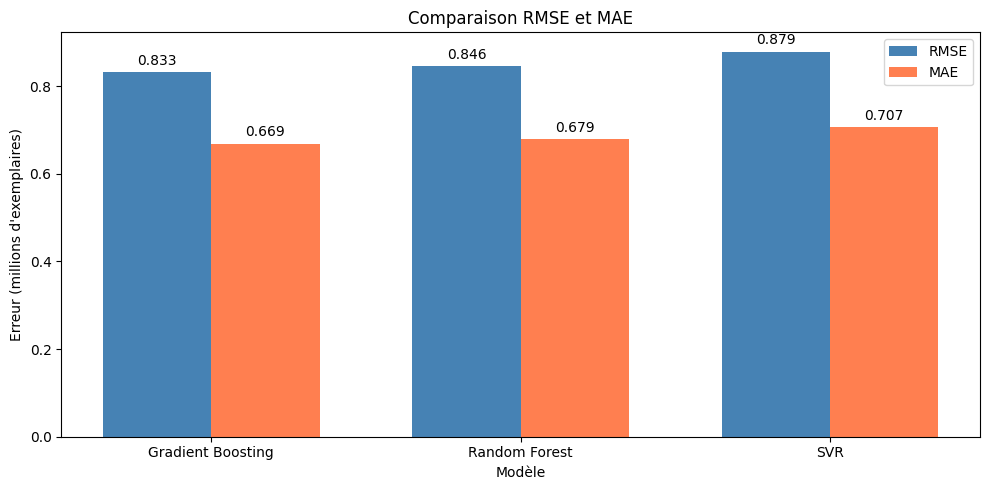

In [127]:
modeles = df_resultats['Modèle'].values
x = np.arange(len(modeles))
largeur = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
barres_rmse = ax.bar(x - largeur/2, df_resultats['RMSE (M)'], largeur, label='RMSE', color='steelblue')
barres_mae  = ax.bar(x + largeur/2, df_resultats['MAE (M)'],  largeur, label='MAE',  color='coral')

ax.set_xlabel('Modèle')
ax.set_ylabel('Erreur (millions d\'exemplaires)')
ax.set_title('Comparaison RMSE et MAE')
ax.set_xticks(x)
ax.set_xticklabels(modeles)
ax.legend()
ax.bar_label(barres_rmse, fmt='%.3f', padding=3)
ax.bar_label(barres_mae,  fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

### Analyse de la comparaison du RMSE et MAE
Ici aussi, une fois de plus, le modèle **Gradient Boosting obtient les meilleurs résultats**. En effet, il a les meilleurs scores avec un RMSE de 0.833 et un MAE de 0.669. Il est par la suite suivi de Random Forest qui obtient un RMSE de 0.846 et un MAE de 0.679 et enfin SVR avec un RMSE de 0.879 et un MAE de 0.707.
Dans notre cas, SVR est le modèle le plus en retrait avec un RMSE de 0.879M et un MAE de 0.707M, soit des erreurs environ 5.5% supérieures aux deux autres modèles.

Cependant, nous avons pu remarquer que les valeurs des RMSE et MAE ont augmentées en comparaison avec le dataset complet :
- Gradient Boosting est passé de RMSE=0.757 et MAE=0.542 à RMSE=0.833 et MAE=0.669
- Random Forest est passé de RMSE=0.763 et MAE=0.550 à RMSE=0.846 et MAE=0.679
- SVR est passé de RMSE=0.810 et MAE=0.603 à RMSE=0.879 et MAE=0.707

L'écart entre RMSE et MAE est d'environ 0,17M pour les trois modèles. Rapporté à la plage de ventes du dataset (0,19M à 1,69M), cet écart reste notable et suggère la présence de valeurs aberrantes au sein même de cette catégorie de jeux à succès modéré.

**Pour conclure, nous pouvons donc en déduire qu'il n'est pas  utile d'utiliser cette version de prédiction de vente d'un jeu, mais qu'au contraire il serait préférable de garder la version préservant le dataset complet**.

## Comparaison des R²

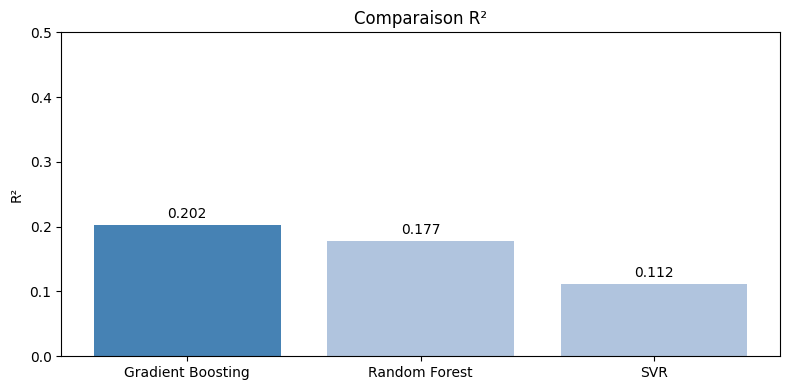

In [128]:
fig, ax = plt.subplots(figsize=(8, 4))
couleurs = ['steelblue' if r == df_resultats['R²'].max() else 'lightsteelblue' for r in df_resultats['R²']]
barres = ax.bar(modeles, df_resultats['R²'], color=couleurs)
ax.set_ylabel('R²')
ax.set_title('Comparaison R²')
ax.set_ylim(0, 0.5)
ax.bar_label(barres, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
print(f"R² train GB : {r2_train_gb:.3f} R² GB LOOCV : {r2_gb:.3f}")
print(f"R² train RF : {r2_train_rf:.3f} R² RF LOOCV : {r2_rf:.3f}")
print(f"R² train SVR : {r2_train_svr:.3f} R² SVR LOOCV : {r2_svr:.3f}")

R² train GB : 0.24796287404178718 R² GB LOOCV : 0.2024660240412406
R² train RF : 0.2896940992719095 R² RF LOOCV : 0.17745238547898545
R² train SVR : 0.1933260832298258 R² SVR LOOCV : 0.11177251539066979


### Analyse de la comparaison des R²
Une fois de plus, Gradient Boosting est le meilleur modèle avec R²=0.202. Ici de même l'ordre ne change pas puisqu'il est d'abord suivi par Random Forest (R²=0.177) et enfin SVR (R²=0.112). 
On remarque cependant une diminution R² pour chaque modèle :
- Gradient Boosting est passé de R²=0.246 à R²=0.202
- Random Forest est passé de R²=0.232 à R²=0.177
- SVR est passé de R²=0.135 à R²=0.112

Au niveau de l'overfitting, on voit une légère baisse du r² pour LOOCV qui passe de 0.248 pour le train à 0.202 pour le LOOCV. Il n'y a donc pas d'overfitting significatif.
Par contre, il y a une baisse plus marquée pour le random forest (0.29 à 0.177). Il apprend bien durant le train mais il a plus de mal à généraliser ensuite.
Enfin, le SVR a également une baisse significative (0.193 à 0.112).

Ainsi, **Gradient Boosting obtient le meilleur résultat** et peut expliquer 20.2% de la variance des ventes. Cependant c'est une valeur trop faible pour envisager une utilisation fiable.
Les performances restent limitées malgré le filtrage du dataset. Malgré l'aménagement des données, près de 80% de la variance des ventes est inexpliquée. Cela confirme que les "features" actuelles sont **insuffisantes pour modéliser efficacement** les facteurs de succès commercial des jeux vidéo.

## Valeurs réelles vs prédites

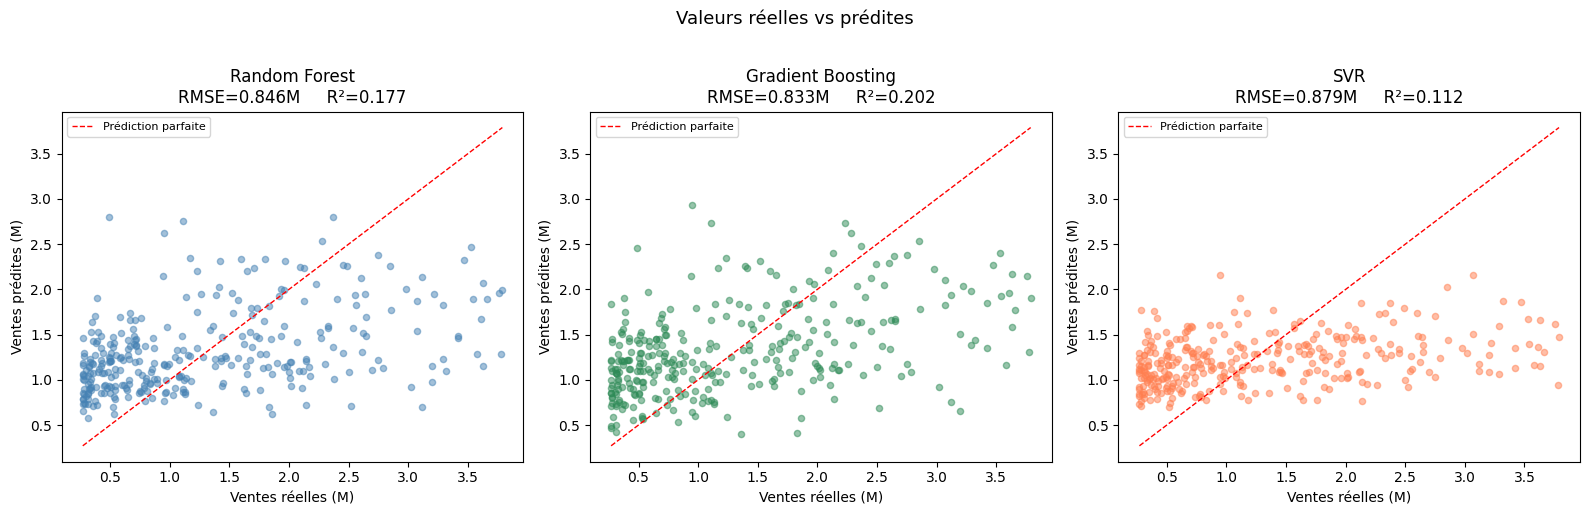

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

donnees = [
    ('Random Forest', y_true_loo, y_pred_loo_rf, rmse_rf, r2_rf, 'steelblue'),
    ('Gradient Boosting', y_true_loo, y_pred_loo_gb, rmse_gb, r2_gb, 'seagreen'),
    ('SVR', y_true_loo, y_pred_loo_svr, rmse_svr, r2_svr, 'coral'),
]

for ax, (nom, y_true, y_pred, rmse, r2, couleur) in zip(axes, donnees):
    ax.scatter(y_true, y_pred, alpha=0.5, color=couleur, s=20)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1, label='Prédiction parfaite')
    ax.set_title(f'{nom}\nRMSE={rmse:.3f}M     R²={r2:.3f}')
    ax.set_xlabel('Ventes réelles (M)')
    ax.set_ylabel('Ventes prédites (M)')
    ax.legend(fontsize=8)

plt.suptitle('Valeurs réelles vs prédites', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Analyse de la comparaison des valeurs réelles vs prédites
- Gradient Boosting :
Avec un RMSE de 0.833 et un R² = 0.202, Gradient Boosting est le plus performant des trois. Ses points s'alignent relativement mieux autour de la ligne rouge pour les ventes faibles à moyennes (0-1,5M). Cependant, comme les autres modèles, il sous-estime systématiquement les ventes élevées (>2M), où les points s'éloignent nettement de la diagonale.

- Random Forest :
Random Forest affiche des résultats très proches (RMSE = 0,846, R² = 0,177). La distribution de ses points (en bleu) est similaire à celle du Gradient Boosting, avec une légère dispersion supplémentaire pour les ventes entre 0 et 1M. Il échoue lui aussi à prédire les valeurs au dessus de 2M.

- SVR :
Le SVR en orange est clairement le moins performant. Avec son RMSE = 0,879 et le R² = 0,112, on voit rapidement visuellement qu'il y a une compression des prédictions vers des valeurs basses. Ce modèle prédit rarement au delà de 1,5M de ventes, quelle que soit la valeur réelle. Il n'arrive pas à prédire les ventes élevées.

**Au final, Gradient Boosting est le meilleur des trois modèles. Il est celui qui a à la fois le RMSE le plus faible et le R² le plus élevé. Il reste néanmoins mauvais sur les valeurs extrêmes, comme les autres modèles.**

On aurait pu s'attendre à ce que réduire la plage de ventes facilite la prédiction, les ventes étant plus homogènes. Pourtant, les performances restent similaires voire moins bonnes qu'avec le dataset complet. Cela est sûrement du au fait que les modèles avaient moins de données disponibles pour l'apprentissage.

# Importance des variables dans nos prédictions
Pour calculer l'importance des variables, il faut que l'on entraîne chaque modèle sur tout le dataset

In [131]:
noms_variables = variables_explicatives  # liste des noms de colonnes

## Random Forest
Pour le modèle random forest, feature_importances_ est intégré pour calculer l'importance des varibales explicatives. Il calcule pour chaque variable combien de fois elle a été utilisée pour faire des coupures dans les arbres, et à quel point ces coupures ont réduit l'erreur ou non

In [132]:
rf_final = RandomForestRegressor(
    n_estimators     = meilleur_n,
    max_depth        = meilleur_depth,
    min_samples_split= meilleur_split,
    random_state     = 42,
    n_jobs           = -1
)
rf_final.fit(X, y)

importances_rf = pd.Series(rf_final.feature_importances_, index=noms_variables)
importances_rf = importances_rf.sort_values()

## Gradient Boosting
Ici aussi, feature_importances_ est intégré

In [133]:
gb_final = GradientBoostingRegressor(**study.best_params, random_state=42)
gb_final.fit(X, y)

importances_gb = pd.Series(gb_final.feature_importances_, index=noms_variables)
importances_gb = importances_gb.sort_values()

## SVR
Pour le SVR, il n'y a pas d'attribut pour calculer l'importance des variables explicatives. 
On doit donc faire une permutation importance. On entraîne le modèle normalement, puis pour chaque variable on mélange aléatoirement ses valeurs entre tous les jeux. Ensuite, on regarde si les prédictions sont moins bonnes qu'avant ou non. Si les prédictions se dégradent, c'est que la variable était importante. Sinon elle était inutile. Le score peut être négatif puisque l'on fait score_original - score_apres_melange. Si il est négatif, c'est que le score est meilleur qu'avant et donc la variable introduisait du bruit, et le modèle marche mieux sans.

In [134]:
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

svr_final = SVR(kernel='rbf', C=meilleur_C, epsilon=meilleur_eps, gamma='scale')
svr_final.fit(X_scaled, y_log)

result = permutation_importance(
    svr_final, X_scaled, y_log,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances_svr = pd.Series(result.importances_mean, index=noms_variables)
importances_svr = importances_svr.sort_values()

## Graphiques

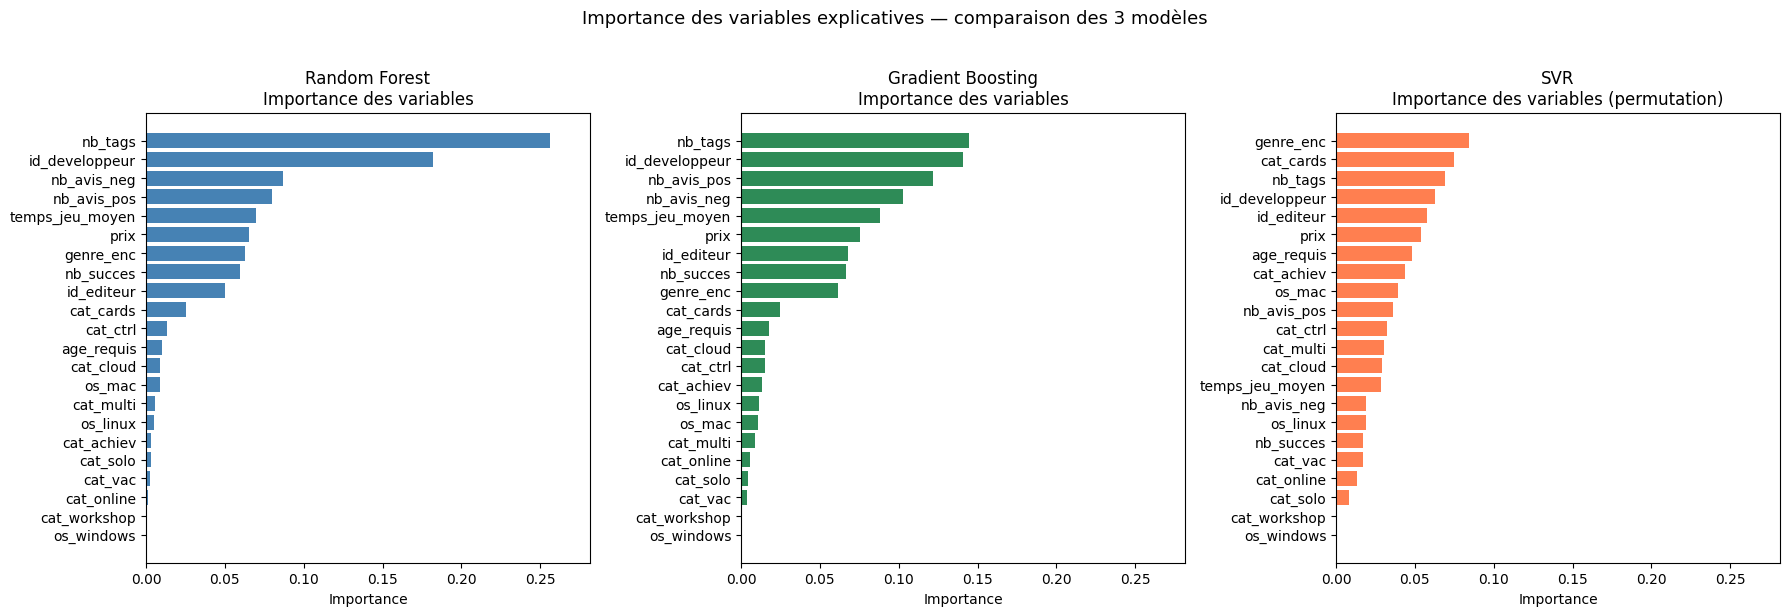

In [135]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Valeur max globale
max_importance = max(
    importances_rf.max(), 
    importances_gb.max(), 
    importances_svr.max()
)

# Random Forest
axes[0].barh(importances_rf.index, importances_rf.values, color='steelblue')
axes[0].set_title('Random Forest\nImportance des variables')
axes[0].set_xlabel('Importance')
axes[0].set_xlim(0, max_importance * 1.1)

# Gradient Boosting
axes[1].barh(importances_gb.index, importances_gb.values, color='seagreen')
axes[1].set_title('Gradient Boosting\nImportance des variables')
axes[1].set_xlabel('Importance')
axes[1].set_xlim(0, max_importance * 1.1)

# SVR
axes[2].barh(importances_svr.index, importances_svr.values, color='coral')
axes[2].set_title('SVR\nImportance des variables (permutation)')
axes[2].set_xlabel('Importance')
axes[2].set_xlim(0, max_importance * 1.1)

plt.suptitle('Importance des variables explicatives — comparaison des 3 modèles', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Analyse des graphes sur l'importance des variables

Ici encore, pour le modèle SVR, aucune variable n'est négative. Donc, aucune variable ne dégrade les prédictions.
On observe que le graphe SVR est celui qui a, une fois de plus, le plus de variables dites explicatives, avec un tiers des variables qui sont au-dessus de 0,04. Cela signifie que toutes ces variables comptent respectivement pour 0,04. **Pour résumer, presque toutes les variables sont importantes dans ce modèle, ce qui explique le manque de précision du SVR.**


Concernant les valeurs observées dans leur globalité, on remarque que la variable "nb_tags" est toujours bien classée, que ce soit avec le modèle Random Forest et Gradient Boosting où il est premier ou encore avec le modèle SVR où il est troisième. Dans le cas du modèle Random Forest, "nb_tags" représente environ 26% de l'importance totale du modèle, ce qui est plus qu'avec le modèle précédent, qui était de 17%. **Pour Gradient Boosting, "nb_tags" environ 14% de l'importance totale du modèle**. Ces valeurs sont plutôt grandes pour le jeu de données que nous avons.

On remarque surtout que **pour les modèles Random Forest et Gradient Boosting, les 6 premières variables explicatives des modèles sont les mêmes**. Soit dans l'ordre : **"nb_tags", "id_developpeur", "nb_avis_neg", "nb_avis_pos", "temps_jeu_moyen" et "prix"**.
Cela voudrait dire que ces 6 variables sont, généralement, celles qui permettent le mieux d'expliquer les ventes d'un jeu. Ces 6 variables sont les plus importantes pour ces deux modèles.

Cependant elles n'ont pas le même poids sur les différents modèles. Par exemple, "nb_tags" a beau être la variable la plus importante pour ces deux modèles, pour **Random Forest** elle représente **environ 26% de l'importance totale du modèle**, tandis que pour **Gradient Boosting**, elle représente **environ 14% de l'importance totale du modèle**.

2 variables ressortent sur les 3 modèles :
- La variable **"nb_tags" est importante partout**. On peut penser qu'un jeu avec beaucoup de tags Steam est probablement plus populaire.
- La variable "id_developpeur" compte beaucoup pour les trois modèles. Ainsi, le studio qui développe le jeu influence les ventes.

**Beaucoup de variables sont très peu utiles** pour chaque modèle car elles sont tout le temps proches de 0 :
- cat_workshop, cat_windows, et d'autres

Ces catégories ne permettent donc pas d'expliquer les ventes d'un jeu, quel que soit le modèle sélectionné.

# Modèles de prédiction pour les jeux avec peu de ventes
Comme dit précedemment, nous avions vu qu'il semblait il y avait 2 catégories de jeux vidéos. Nous allons donc maintenant tester des prédictions sur les jeux à faible ventes (en dessous de 0.51M).

# Nettoyage et préparation des données

## Connexion à la DB

In [136]:
connexion = mysql.connector.connect(
    host     = 'localhost',
    user     = 'root',
    password = '',
    database = 'gamesale'
)

## Création des dataframe

In [137]:
# Table principale
df = pd.read_sql("""
    SELECT
        id_jeu,
        nom_jeu,
        age_requis,
        nb_succes,
        nb_avis_pos,
        nb_avis_neg,
        temps_jeu_moyen,
        prix,
        ventes_Global
    FROM jeux
""", connexion)

# Conversion ventes (virgule/point)
df['ventes_Global'] = df['ventes_Global'].str.replace(',', '.').astype(float)

# Genre (un seul par jeu, on prend le premier)
df_genre = pd.read_sql("""
    SELECT id_jeu, genre
    FROM genre
    GROUP BY id_jeu
""", connexion)

# Éditeur (un seul par jeu)
df_edit = pd.read_sql("""
    SELECT id_jeu, id_editeur
    FROM editeur
    GROUP BY id_jeu
""", connexion)

# Développeur (un seul par jeu)
df_dev = pd.read_sql("""
    SELECT id_jeu, id_developpeur
    FROM developpeur
    GROUP BY id_jeu
""", connexion)

# OS (colonnes binaires 0/1)
df_os = pd.read_sql("""
    SELECT
        id_jeu,
        MAX(CASE WHEN id_os = 1 THEN 1 ELSE 0 END) AS os_windows,
        MAX(CASE WHEN id_os = 2 THEN 1 ELSE 0 END) AS os_mac,
        MAX(CASE WHEN id_os = 3 THEN 1 ELSE 0 END) AS os_linux
    FROM a_os
    GROUP BY id_jeu
""", connexion)

# Catégories (colonnes binaires 0/1)
df_cat = pd.read_sql("""
    SELECT
        id_jeu,
        MAX(CASE WHEN id_cat = '1'  THEN 1 ELSE 0 END) AS cat_multi,
        MAX(CASE WHEN id_cat = '2'  THEN 1 ELSE 0 END) AS cat_online,
        MAX(CASE WHEN id_cat = '4'  THEN 1 ELSE 0 END) AS cat_vac,
        MAX(CASE WHEN id_cat = '5'  THEN 1 ELSE 0 END) AS cat_solo,
        MAX(CASE WHEN id_cat = '6'  THEN 1 ELSE 0 END) AS cat_cloud,
        MAX(CASE WHEN id_cat = '7'  THEN 1 ELSE 0 END) AS cat_achiev,
        MAX(CASE WHEN id_cat = '8'  THEN 1 ELSE 0 END) AS cat_cards,
        MAX(CASE WHEN id_cat = '10' THEN 1 ELSE 0 END) AS cat_ctrl,
        MAX(CASE WHEN id_cat = '22' THEN 1 ELSE 0 END) AS cat_workshop
    FROM a_categorie
    GROUP BY id_jeu
""", connexion)

# Nombre de tags par jeu
curseur = connexion.cursor()
curseur.execute("SELECT * FROM a_tag LIMIT 1")
curseur.fetchall()
toutes_cols   = [description[0] for description in curseur.description]
colonnes_tags = toutes_cols[1:]
somme_tags    = ' + '.join([f'`{col}`' for col in colonnes_tags])

df_tags = pd.read_sql(f"""
    SELECT id_jeu, ({somme_tags}) AS nb_tags
    FROM a_tag
""", connexion)

connexion.close()

## Fusion des dataframe

In [138]:
df = df.merge(df_genre, on='id_jeu', how='left')
df = df.merge(df_edit,  on='id_jeu', how='left')
df = df.merge(df_dev,   on='id_jeu', how='left')
df = df.merge(df_os,    on='id_jeu', how='left')
df = df.merge(df_cat,   on='id_jeu', how='left')
df = df.merge(df_tags,  on='id_jeu', how='left')

print(f"Après fusion : {len(df)} jeux, {len(df.columns)} colonnes")

Après fusion : 780 jeux, 25 colonnes


## Nettoyage des données

In [139]:
# Supprimer les lignes avec des NaN dans les colonnes essentielles
df = df.dropna(subset=['ventes_Global', 'age_requis', 'prix'])

# Remplir les NaN restants
df['genre']          = df['genre'].fillna('Unknown')
df['id_editeur']     = df['id_editeur'].fillna(-1).astype(int)
df['id_developpeur'] = df['id_developpeur'].fillna(-1).astype(int)
df['nb_tags']        = df['nb_tags'].fillna(0)
df = df.fillna(0)

print(f"Après nettoyage NaN : {len(df)} jeux")

Après nettoyage NaN : 780 jeux


## Filtrage des données (retirer quantile>0.7)
On garde les jeux à faible ventes, donc des jeux à moins de 0.51M de ventes.

In [140]:
seuil_70 = df['ventes_Global'].quantile(0.70)
df = df[df['ventes_Global'] <= seuil_70]

print(f"Après suppression des jeux au dessus du 7ème décile : {len(df)} jeux")

Après suppression des jeux au dessus du 7ème décile : 546 jeux


## Encodage des variables catégorielles non encodées (genre)

In [141]:
le_genre = LabelEncoder() #chaque catégorie est remplacée par un nombre entier
df['genre_enc'] = le_genre.fit_transform(df['genre'])

## Variables explicatives

In [142]:
variables_explicatives = [
    'age_requis',
    'nb_succes',
    'nb_avis_pos',
    'nb_avis_neg',
    'temps_jeu_moyen',
    'prix',
    'genre_enc',
    'id_editeur',
    'id_developpeur',
    'os_windows',
    'os_mac',
    'os_linux',
    'cat_multi',
    'cat_online',
    'cat_vac',
    'cat_solo',
    'cat_cloud',
    'cat_achiev',
    'cat_cards',
    'cat_ctrl',
    'cat_workshop',
    'nb_tags',
]

X   = df[variables_explicatives]
y   = df['ventes_Global'].values     # ventes réelles (en millions)
y_log = np.log1p(y)                  # ventes log pour SVR

print(f"\nDataset final : {X.shape[0]} jeux, {X.shape[1]} features")
print(f"Ventes :\nmin: {y.min():.2f}M - max: {y.max():.2f}M - moyenne: {y.mean():.2f}M")
print(f"\nVariables explicatives utilisées :\n")
for f in variables_explicatives:
    print(f"  - {f}")


Dataset final : 546 jeux, 22 features
Ventes :
min: 0.01M - max: 1.04M - moyenne: 0.23M

Variables explicatives utilisées :

  - age_requis
  - nb_succes
  - nb_avis_pos
  - nb_avis_neg
  - temps_jeu_moyen
  - prix
  - genre_enc
  - id_editeur
  - id_developpeur
  - os_windows
  - os_mac
  - os_linux
  - cat_multi
  - cat_online
  - cat_vac
  - cat_solo
  - cat_cloud
  - cat_achiev
  - cat_cards
  - cat_ctrl
  - cat_workshop
  - nb_tags


# Tuning et entraînement des modèles

## Random Forest

### Tuning train/test
Recherche des meilleurs hyperparamètres

In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

meilleur_rmse = np.inf
r2_train_rf = None
meilleur_n, meilleur_depth, meilleur_split = None, None, None

for n_estimators in [100, 200, 300, 500]:
    for max_depth in [None, 5, 10, 15, 20]:
        for min_samples_split in [2, 5, 10]:

            rf = RandomForestRegressor(
                n_estimators     = n_estimators,
                max_depth        = max_depth,
                min_samples_split= min_samples_split,
                random_state     = 42
            )
            rf.fit(X_train, y_train)
            y_pred = rf.predict(X_test)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2= r2_score(y_test,y_pred)

            if rmse < meilleur_rmse:
                meilleur_rmse  = rmse
                r2_train_rf    = r2 
                meilleur_n     = n_estimators
                meilleur_depth = max_depth
                meilleur_split = min_samples_split

print(f"Meilleurs hyperparamètres : n_estimators={meilleur_n}, max_depth={meilleur_depth}, min_samples_split={meilleur_split}")
print(f"RMSE sur train/test : {meilleur_rmse:.3f}M")

Meilleurs hyperparamètres : n_estimators=500, max_depth=5, min_samples_split=5
RMSE sur train/test : 0.260M


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [144]:
#6mins40s pour faire tourner ce chunck avec un processeur 13th Gen Intel(R) Core(TM) i7-13620H (2.40 GHz)
loo = LeaveOneOut()
liste_reelles  = []
liste_predites = []

for train_idx, test_idx in loo.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    rf = RandomForestRegressor(
        n_estimators= meilleur_n,
        max_depth= meilleur_depth,
        min_samples_split= meilleur_split,
        random_state= 42,
        n_jobs=-1 #utilise tous les coeurs des processeurs car ça prenait + de 20mins
    )
    rf.fit(X_tr, y_tr)

    pred = rf.predict(X_te)[0]
    liste_predites.append(pred)
    liste_reelles.append(y_te[0])

y_pred_loo = np.array(liste_predites)
y_true_loo = np.array(liste_reelles)

### Résultats

In [145]:
rmse_rf = np.sqrt(mean_squared_error(y_true_loo, y_pred_loo))
mae_rf  = mean_absolute_error(y_true_loo, y_pred_loo)
r2_rf   = r2_score(y_true_loo, y_pred_loo)
y_pred_loo_rf = y_pred_loo.copy() #sauvegarde pour les graphiques

print(f"\nRésultats Random Forest")
print(f"  RMSE : {rmse_rf:.3f}M En moyenne le modèle se trompe de +-{rmse_rf:.2f} millions")
print(f"  MAE  : {mae_rf:.3f}M")
print(f"  R²   : {r2_rf:.3f}  Le modèle explique {r2_rf*100:.1f}% de la variance des ventes")


Résultats Random Forest
  RMSE : 0.229M En moyenne le modèle se trompe de +-0.23 millions
  MAE  : 0.173M
  R²   : 0.169  Le modèle explique 16.9% de la variance des ventes


## Gradient Boosting

### Tuning train/test et optuna
Recherche des meilleurs hyperparamètres. On utilise optuna qui cherche automatiquement les meilleurs hyperparamètres en 100 essais. Il oriente intelligemment les essais vers les meilleures combinaisons en minimisant le RMSE.

In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500, step=50),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 2, 8),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }

    modele = GradientBoostingRegressor(**params, random_state=42)

    # On tune sur RMSE (donc on minimise MSE)
    scores = cross_val_score(
        modele, X_train, y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    return -scores.mean()  # on minimise donc on inverse

optuna.logging.set_verbosity(optuna.logging.WARNING) #enlève les messages d'info affiché à chaque trial

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)

study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Meilleurs hyperparamètres Optuna : {study.best_params}")
print(f"Meilleur RMSE (cross-val 5 folds) : {study.best_value:.3f}M")

meilleur_modele = GradientBoostingRegressor(**study.best_params, random_state=42)
meilleur_modele.fit(X_train, y_train)
y_pred = meilleur_modele.predict(X_test)
r2_train_gb = r2_score(y_test, y_pred)
meilleur_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE sur train/test : {meilleur_rmse:.3f}M")
print(f"R² sur train/test : {r2_train_gb:.3f}")

  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 56. Best value: 0.219159: 100%|██████████| 100/100 [00:24<00:00,  4.01it/s]


Meilleurs hyperparamètres Optuna : {'n_estimators': 250, 'learning_rate': 0.010171769297497425, 'max_depth': 8, 'subsample': 0.9933891967115743, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 'log2'}
Meilleur RMSE (cross-val 5 folds) : 0.219M
RMSE sur train/test : 0.261M
R² sur train/test : 0.148


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [147]:
#Prend 2mins22s à tourner avec processeur 13th Gen Intel(R) Core(TM) i7-13620H (2.40 GHz)
loo = LeaveOneOut()
liste_reelles  = []
liste_predites = []

modele_final = GradientBoostingRegressor(**study.best_params, random_state=42)

for train_idx, test_idx in loo.split(X):
    # loo.split(X) génère à chaque tour :
    #   - train_idx : les indices des jeux utilisés pour l'entraînement
    #   - test_idx  : l'indice du jeu qu'on veut prédire (toujours 1 seul)

    # On découpe X et y en données d'entraînement et de test
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    #Entrainement
    # On entraîne le modèle sur les données d'entraînement
    modele_final.fit(X_tr, y_tr)

    #Prédiction 
    # On prédit les ventes du jeu de test
    # [0] car predict() retourne une liste, on veut juste le premier élément
    pred = modele_final.predict(X_te)[0]
    liste_predites.append(pred)
    liste_reelles.append(y_te[0])

# On stocke les résultats
y_pred_loo = np.array(liste_predites)
y_true_loo = np.array(liste_reelles)

### Résultats

In [148]:
rmse_gb = np.sqrt(mean_squared_error(y_true_loo, y_pred_loo))
mae_gb  = mean_absolute_error(y_true_loo, y_pred_loo)
r2_gb   = r2_score(y_true_loo, y_pred_loo)
y_pred_loo_gb = y_pred_loo.copy() #sauvegarde pour les graphiques

print(f"\nRésultats Gradient Boosting")
print(f"  RMSE : {rmse_gb:.3f}M  En moyenne le modèle se trompe de +-{rmse_gb:.2f} millions")
print(f"  MAE  : {mae_gb:.3f}M")
print(f"  R²   : {r2_gb:.3f}  Le modèle explique {r2_gb*100:.1f}% de la variance des ventes")


Résultats Gradient Boosting
  RMSE : 0.229M  En moyenne le modèle se trompe de +-0.23 millions
  MAE  : 0.173M
  R²   : 0.173  Le modèle explique 17.3% de la variance des ventes


## Support Vector Regression

### Tuning train/test
Recherche des meilleurs hyperparamètres

In [149]:
# Le SVR a besoin de y_log pour l'entraînement (stabilise la distribution)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Récupérer y réel pour les métriques
_, _, y_train_reel, y_test_reel = train_test_split(
    X, y, test_size=0.2, random_state=42
)

meilleur_rmse = np.inf
r2_train_svr = None
meilleur_C, meilleur_eps = None, None

for C in [0.1,0.5,1,2,3,4,5,6,7]:
    for eps in [0.35, 0.36,0.37,0.38]:

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        svr = SVR(kernel='rbf', C=C, epsilon=eps, gamma='scale')
        svr.fit(X_train_scaled, y_train_log)

        # Prédiction sur échelle réelle pour le RMSE
        y_pred_log  = svr.predict(X_test_scaled)
        y_pred_reel = np.expm1(y_pred_log)

        rmse = np.sqrt(mean_squared_error(y_test_reel, y_pred_reel))
        r2=r2_score(y_test_reel,y_pred_reel)

        if rmse < meilleur_rmse:
            meilleur_rmse = rmse
            r2_train_svr  = r2
            meilleur_C    = C
            meilleur_eps  = eps

print(f"Meilleurs hyperparamètres : C={meilleur_C}, epsilon={meilleur_eps}")
print(f"Meilleur RMSE sur train/test : {meilleur_rmse:.3f}M")

Meilleurs hyperparamètres : C=0.1, epsilon=0.35
Meilleur RMSE sur train/test : 0.318M


### Evaluation par LOOCV avec les meilleurs hyperparamètres
Mesure des performances avec les hyperparamètres trouvés

In [150]:
loo = LeaveOneOut()
liste_reelles  = []
liste_predites = []

for train_idx, test_idx in loo.split(X):
    X_tr, X_te   = X.iloc[train_idx], X.iloc[test_idx]
    y_tr_log     = y_log[train_idx]
    y_te_reel    = y[test_idx]

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    svr = SVR(kernel='rbf', C=meilleur_C, epsilon=meilleur_eps, gamma='scale')
    svr.fit(X_tr_scaled, y_tr_log)

    pred_log  = svr.predict(X_te_scaled)[0]
    pred_reel = np.expm1(pred_log)

    liste_predites.append(pred_reel)
    liste_reelles.append(float(y_te_reel[0]))

y_pred_loo = np.array(liste_predites)
y_true_loo = np.array(liste_reelles)

### Résultats

In [151]:
rmse_svr = np.sqrt(mean_squared_error(y_true_loo, y_pred_loo))
mae_svr  = mean_absolute_error(y_true_loo, y_pred_loo)
r2_svr   = r2_score(y_true_loo, y_pred_loo)
y_pred_loo_svr = y_pred_loo.copy() #sauvegarde pour les graphiques

print(f"\nRésultats SVR")
print(f"  RMSE : {rmse_svr:.3f}M  En moyenne le modèle se trompe de +-{rmse_svr:.2f} millions")
print(f"  MAE  : {mae_svr:.3f}M")
print(f"  R²   : {r2_svr:.3f}  Le modèle explique {r2_svr*100:.1f}% de la variance des ventes")


Résultats SVR
  RMSE : 0.324M  En moyenne le modèle se trompe de +-0.32 millions
  MAE  : 0.300M
  R²   : -0.663  Le modèle explique -66.3% de la variance des ventes


# Comparaison des modèles

## Tableau récapitulatif

In [152]:
resultats = {
    'Modèle':             ['Random Forest', 'Gradient Boosting', 'SVR'],
    'RMSE (M)':           [rmse_rf, rmse_gb, rmse_svr],
    'MAE (M)':            [mae_rf,  mae_gb,  mae_svr],
    'R²':                 [r2_rf,   r2_gb,   r2_svr],
}

import pandas as pd
df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values('RMSE (M)')
print(df_resultats.to_string(index=False))

           Modèle  RMSE (M)  MAE (M)        R²
Gradient Boosting  0.228529 0.172740  0.173317
    Random Forest  0.229096 0.173204  0.169214
              SVR  0.324138 0.299838 -0.663085


## Comparaison RMSE et MAE

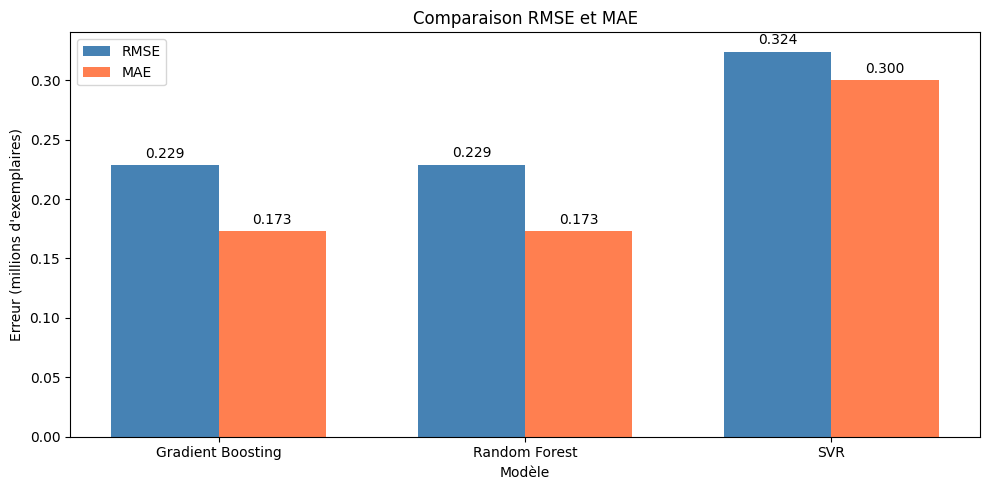

In [153]:
modeles = df_resultats['Modèle'].values
x = np.arange(len(modeles))
largeur = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
barres_rmse = ax.bar(x - largeur/2, df_resultats['RMSE (M)'], largeur, label='RMSE', color='steelblue')
barres_mae  = ax.bar(x + largeur/2, df_resultats['MAE (M)'],  largeur, label='MAE',  color='coral')

ax.set_xlabel('Modèle')
ax.set_ylabel('Erreur (millions d\'exemplaires)')
ax.set_title('Comparaison RMSE et MAE')
ax.set_xticks(x)
ax.set_xticklabels(modeles)
ax.legend()
ax.bar_label(barres_rmse, fmt='%.3f', padding=3)
ax.bar_label(barres_mae,  fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

### Analyse de la comparaison du RMSE et MAE
Ici, **Gradient Boosting a cette fois ci les mêmes résultats que Random Forest**. En effet, Gradient Boosting a les meilleurs scores avec un RMSE de 0.229 et un MAE de 0.173, suivi de Random Forest avec un RMSE de 0.229 et un MAE de 0.173 et enfin SVR avec un RMSE de 0.324 et un MAE de 0.300.
Dans ce cas précis, SVR est le modèle toujours en retrait avec des valeurs toujours plus grandes ques les deux autres modèles, soit un RMSE de 0.324 et un MAE de 0.300, soit des erreurs environ 41.5% et 73.4% supérieures aux deux autres modèles.

Cependant, on remarque que les valeurs des RMSE et MAE ont beaucoup diminué en comparaison avec le dataset complet :
- Gradient Boosting est passé de RMSE = 0.757 et MAE = 0.542 à RMSE = 0.229 et MAE = 0.173
- Random Forest est passé de RMSE = 0.763 et MAE = 0.550 à RMSE = 0.229 et MAE = 0.173
- SVR est passé de RMSE = 0.810 et MAE = 0.603 à RMSE = 0.324 et MAE = 0.300

Nous pouvons également remarquer une absence de valeurs aberrantes. En effet, l'écart RMSE/MAE de Gradient Boosting et de Random Forest est de 0,056M, ce qui est faible par rapport à la plage de ventes (0-0,51M). Ce n'était pas le cas avec les deux derniers filtrages.

**Cette fois-ci, on remarque que le RMSE et la MAE sont bien plus faibles avec cette version du dataset. Ainsi, nos modèles de prédictions marchent le mieux pour les jeux qui sont dans la norme, c'est-à-dire les jeux à faibles ventes (en dessous de 0,51M), qui constituent la majorité du dataset.**

## Comparaison des R²

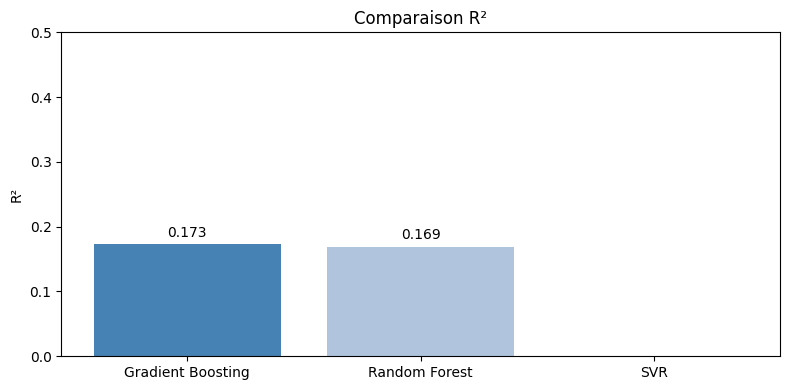

In [154]:
fig, ax = plt.subplots(figsize=(8, 4))
couleurs = ['steelblue' if r == df_resultats['R²'].max() else 'lightsteelblue' for r in df_resultats['R²']]
barres = ax.bar(modeles, df_resultats['R²'], color=couleurs)
ax.set_ylabel('R²')
ax.set_title('Comparaison R²')
ax.set_ylim(0, 0.5)
ax.bar_label(barres, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
print(f"R² train GB : {r2_train_gb:.3f} R² GB LOOCV : {r2_gb:.3f}")
print(f"R² train RF : {r2_train_rf:.3f} R² RF LOOCV : {r2_rf:.3f}")
print(f"R² train SVR : {r2_train_svr:.3f} R² SVR LOOCV : {r2_svr:.3f}")

R² train GB : 0.14792356828386555 R² GB LOOCV : 0.17331680006781103
R² train RF : 0.1537269502741685 R² RF LOOCV : 0.1692137419572426
R² train SVR : -0.2653292552964661 R² SVR LOOCV : -0.6630851103570001


### Analyse de la comparaison des R²

Pour la dernière comparaison des R², Gradient Boosting est encore devant avec R² = 0.173, suivi de Random Forest (R² = 0.169) et SVR (R² = -0.663). On remarque une baisse du R² pour chaque modèle :
- Gradient Boosting est passé de R² = 0.246 (score dataset complet) à R² = 0.173
- Random Forest est passé de R² = 0.232 (score dataset complet) à R² = 0.169
- SVR est passé de R² = 0.135 (score dataset complet) à R² = -0.663. La barre n'apparaît pas sur le graphique puisque sa valeur est négative.

On remarque également que les r² de LOOCV sont supérieurs au r² train/test pour random forest et gradient boosting, ce qui surggère qu'il n'y a pas d'overfitting.
Pour le SVR, le r² est encore plus négatif pour le LOOCV, ce qui confirme que le SVR n'est pas adapté à ce dataset.

On remarque ici que la valeur du **R² pour le modèle SVR est négative**. Ce qui veut dire que **SVR fait pire que de prédire** la moyenne des ventes. **Le modèle est plus faible qu'une prédiction naïve qui prédirait toujours la moyenne**.
Les performances restent globalement faibles. Malgré l'aménagement des données, près de 80% de la variance des ventes reste inexpliqué, confirmant que les features actuelles sont insuffisantes pour modéliser efficacement les facteurs de succès commercial des jeux vidéo.

## Valeurs réelles vs prédites

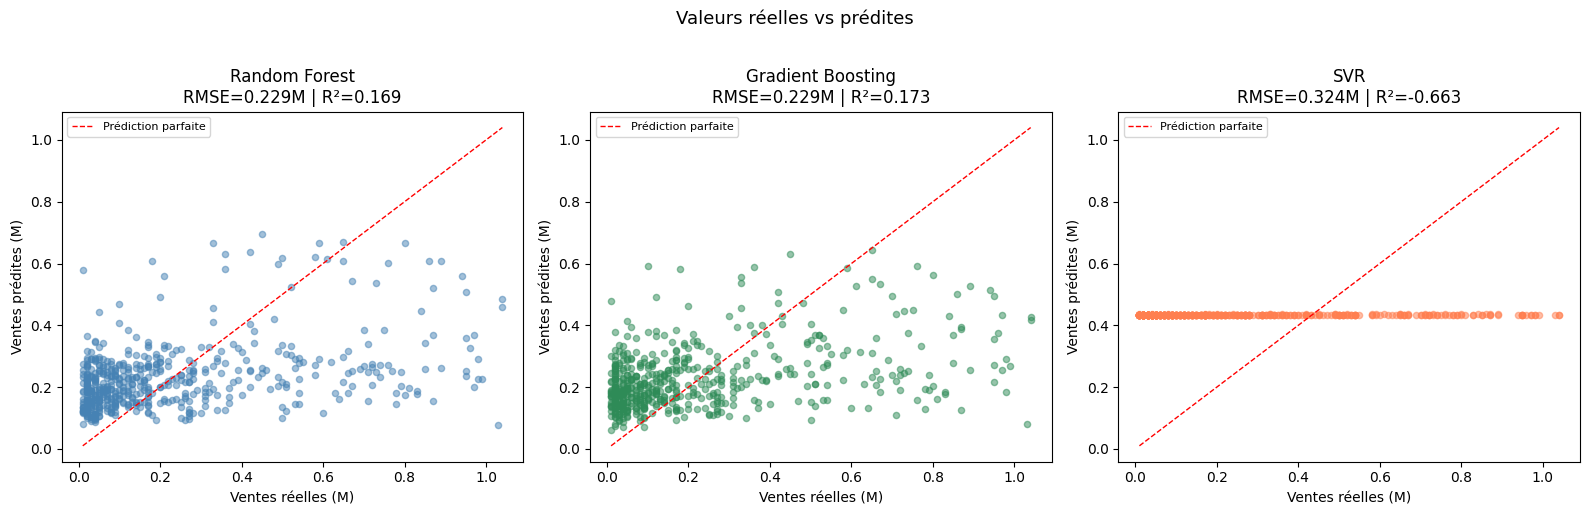

In [156]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

donnees = [
    ('Random Forest', y_true_loo, y_pred_loo_rf, rmse_rf, r2_rf, 'steelblue'),
    ('Gradient Boosting', y_true_loo, y_pred_loo_gb, rmse_gb, r2_gb, 'seagreen'),
    ('SVR', y_true_loo, y_pred_loo_svr, rmse_svr, r2_svr, 'coral'),
]

for ax, (nom, y_true, y_pred, rmse, r2, couleur) in zip(axes, donnees):
    ax.scatter(y_true, y_pred, alpha=0.5, color=couleur, s=20)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1, label='Prédiction parfaite')
    ax.set_title(f'{nom}\nRMSE={rmse:.3f}M | R²={r2:.3f}')
    ax.set_xlabel('Ventes réelles (M)')
    ax.set_ylabel('Ventes prédites (M)')
    ax.legend(fontsize=8)

plt.suptitle('Valeurs réelles vs prédites', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Analyse de la comparaison des valeurs réelles vs prédites

- Gradient Boosting :
Avec un RMSE de 0,229 et un R² = 0,173, Gradient Boosting est le plus performant des trois. Ses points s'alignent relativement mieux autour de la ligne rouge pour les ventes faibles à moyennes (0–0,4M). Cependant, au-delà de 0,4M, la dispersion augmente nettement et les prédictions deviennent peu fiables. Gradient Boosting est légèrement supérieur à Random Forest grâce à son R² plus élevé.
- Random Forest :
Random Forest affiche des résultats identiques (RMSE = 0,229, R² = 0,169). La distribution de ses points est similaire à celle du Gradient Boosting, avec une dispersion comparable sur la plage 0–0,4M. Il échoue lui aussi à prédire de manière fiable les valeurs au-dessus de 0,4M.
- SVR :
SVR est de loin le moins performant, avec un RMSE = 0,324 et un R² = -0,663. Ce R² négatif confirme que le modèle fait pire qu'une prédiction naïve. Cela se voit clairement sur le graphique : SVR prédit quasi systématiquement des ventes autour de 0,42M, quelle que soit la valeur réelle, ce qui explique son incapacité totale à capturer les variations du dataset.

**Pour conclure, Gradient Boosting reste le meilleur des trois modèles. Il a encore une fois le RMSE le plus faible et le R² le plus élevé. Il reste néanmoins mauvais sur les valeurs extrêmes, comme les autres modèles.**
Il semble être le plus fiable pour la prédiction malgré ses résultats mauvais. Cependant, ses performances globales restent insuffisantes pour une réelle utilisation.

# Importance des variables dans nos prédictions
Pour calculer l'importance des variables, il faut que l'on entraîne chaque modèle sur tout le dataset

In [157]:
noms_variables = variables_explicatives  # liste des noms de colonnes

## Random Forest
Pour le modèle random forest, feature_importances_ est intégré pour calculer l'importance des varibales explicatives. Il calcule pour chaque variable combien de fois elle a été utilisée pour faire des coupures dans les arbres, et à quel point ces coupures ont réduit l'erreur ou non

In [158]:
rf_final = RandomForestRegressor(
    n_estimators     = meilleur_n,
    max_depth        = meilleur_depth,
    min_samples_split= meilleur_split,
    random_state     = 42,
    n_jobs           = -1
)
rf_final.fit(X, y)

importances_rf = pd.Series(rf_final.feature_importances_, index=noms_variables)
importances_rf = importances_rf.sort_values()

## Gradient Boosting
Ici aussi, feature_importances_ est intégré

In [159]:
gb_final = GradientBoostingRegressor(**study.best_params, random_state=42)
gb_final.fit(X, y)

importances_gb = pd.Series(gb_final.feature_importances_, index=noms_variables)
importances_gb = importances_gb.sort_values()

## SVR
Pour le SVR, il n'y a pas d'attribut pour calculer l'importance des variables explicatives. 
On doit donc faire une permutation importance. On entraîne le modèle normalement, puis pour chaque variable on mélange aléatoirement ses valeurs entre tous les jeux. Ensuite, on regarde si les prédictions sont moins bonnes qu'avant ou non. Si les prédictions se dégradent, c'est que la variable était importante. Sinon elle était inutile. Le score peut être négatif puisque l'on fait score_original - score_apres_melange. Si il est négatif, c'est que le score est meilleur qu'avant et donc la variable introduisait du bruit, et le modèle marche mieux sans.

In [160]:
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

svr_final = SVR(kernel='rbf', C=meilleur_C, epsilon=meilleur_eps, gamma='scale')
svr_final.fit(X_scaled, y_log)

result = permutation_importance(
    svr_final, X_scaled, y_log,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances_svr = pd.Series(result.importances_mean, index=noms_variables)
importances_svr = importances_svr.sort_values()

## Graphiques

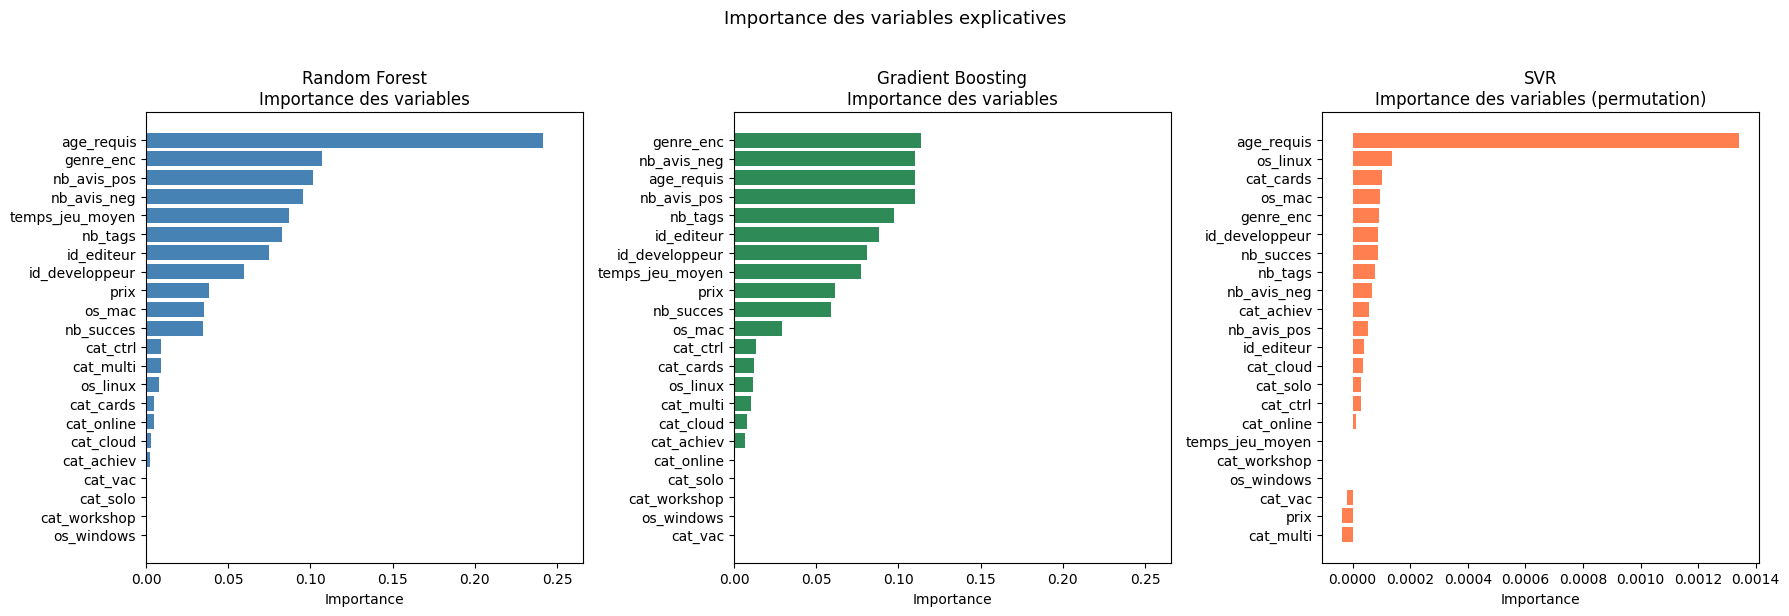

In [161]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Valeur max globale
max_importance = max(
    importances_rf.max(), 
    importances_gb.max(), 
)

# Random Forest
axes[0].barh(importances_rf.index, importances_rf.values, color='steelblue')
axes[0].set_title('Random Forest\nImportance des variables')
axes[0].set_xlabel('Importance')
axes[0].set_xlim(0, max_importance * 1.1)

# Gradient Boosting
axes[1].barh(importances_gb.index, importances_gb.values, color='seagreen')
axes[1].set_title('Gradient Boosting\nImportance des variables')
axes[1].set_xlabel('Importance')
axes[1].set_xlim(0, max_importance * 1.1)

# SVR
axes[2].barh(importances_svr.index, importances_svr.values, color='coral')
axes[2].set_title('SVR\nImportance des variables (permutation)')
axes[2].set_xlabel('Importance')

plt.suptitle('Importance des variables explicatives', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Analyse des graphes sur l'importance des variables

Cette fois-ci, le modèle SVR possède des variables négatives. Ces variables dégradent les prédictions, ce qui rend le modèle encore moins efficace que d'habitude. De plus, "age_requis" domine très largement les autres variables dans ce modèle. C'est sûrement pour cela que ce modèle prédit toujours la même valeur autour de 0.4.

Concernant les valeurs observées dans leur globalité, on remarque que la variable "nb_tags" n'est plus aussi bien classée qu'avant, que ce soit avec le modèle Random Forest et Gradient Boosting, où elle est passée respectivement de première à 6ème et 5ème.
La variable "nb_tags" est alors devenue bien moins importante pour les modèles de prédictions.

Cependant, les 4 variables les plus importantes pour nos deux modèles RF et GB sont les variables : "age_requis", "genre_enc", "nb_avis_neg" et "nb_avis_pos", bien que l'ordre diffère entre les deux. On peut notamment voir que **"age_requis" représente environ 24% (avant 17%) de l'importance totale du modèle Random Forest**. Pour Gradient Boosting, "age_requis" représente environ 11% de l'importance totale du modèle.
Ces valeurs sont, encore une fois, plutôt grandes pour le jeu de données que nous avons.
Ainsi, ces 4 variables sont celles qui permettent le mieux d'expliquer les ventes d'un jeu. Elles sont les plus importantes pour ces deux modèles malgré leur différence d'importance.

2 variables ressortent sur les 3 modèles :
- La variable **"genre_enc" est importante pour nos deux modèles**. On peut penser que le genre prédéfini d'un jeu le rend probablement plus populaire.
- La variable "age_requis" compte beaucoup pour les deux modèles. Ainsi, l'âge requis pour jouer à un jeu influence les ventes.

**Beaucoup de variables sont très peu utiles** pour chaque modèle car elles sont tout le temps proches de 0 :
- cat_workshop, os_windows, cat_solo, cat_vac et d'autres

Ces catégories ne permettent donc pas d'expliquer les ventes d'un jeu, quel que soit le modèle sélectionné.

# Conclusion

**Dataset complet** :
- R² : GB=0.246 | RF=0.232 | SVR=0.135 Meilleur: **GB**
- RMSE: GB=0.757| RF=0.762 | SVR=0.831 Meilleur: **GB**
- MAE : GB=0.603| RF=0.608 | SVR=0.664 Meilleur: **GB**

**Jeux moyens** :
- R² : GB=0.202 | RF=0.177 | SVR=0.112 Meilleur: **GB**
- RMSE: GB=0.833| RF=0.846 | SVR=0.879 Meilleur: **GB**
- MAE : GB=0.669| RF=0.679 | SVR=0.707 Meilleur: **GB**

**Petits jeux** :
- R² : GB=0.173 | RF=0.169 | SVR=-0.663 Meilleur: **GB**
- RMSE: GB=0.229| RF=0.229 | SVR=0.324 Meilleur: **GB=RF**
- MAE : GB=0.173| RF=0.173 | SVR=0.300 Meilleur: **GB=RF**

**BILAN** : GB **meilleur ou égal partout**


**Conclusion :**
Gradient Boosting **domine ou égale Random Forest partout** et offre les **meilleures prédictions** malgré des R² faibles (max 24,6%, moyenne environ 20%). SVR quant à lui n'est jamais le meilleur. Gradient Boosting est alors le meilleur choix pour prédire les ventes de jeu parmi ces 3 modèles, bien que pas assez fonctionnel pour réellement le déployer.